# Component Decomposition of Global Mean Sea Level Rise

This notebook implements the staged component decomposition described in
`hierarchical_slr_framework.tex` §3 and `component_decomposition_plan.md`.

**Stage 1 (this notebook):** Thermosteric decomposition — fit the thermal-expansion
component separately, then compute the cryospheric + TWS residual.

Key data source: Frederikse et al. (2020) budget-closure reconstruction,
which already provides component-level decomposition (steric, glaciers,
Greenland, Antarctica, TWS) from 1900–2018.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

from slr_data_readers import (
    read_glambie_global, read_glambie_regional,
    read_imbie_greenland, read_imbie_east_antarctica,
    read_imbie_antarctic_peninsula, read_imbie_antarctica,
    read_imbie_all,
    read_ipcc_ar6_component, list_ipcc_ar6_components,
    read_noaa_oni, read_noaa_mei,
)
from bayesian_dols import (
    build_level_design_vectors, fit_bayesian_level,
    calibrate_exponential_prior,
)

# Paths
H5_PATH   = '../data/processed/slr_processed_data.h5'
RAW_DIR   = '../data/raw'
FIG_DIR   = '../figures'
COMP_DIR  = f'{RAW_DIR}/ipcc_ar6/slr/ar6/global/dist_components'

# Constants
M_TO_MM = 1000.0
BASELINE_YEAR = 2005.0

print('Imports OK')

Imports OK


## 1. Data Loading

Load the Frederikse et al. (2020) budget-closure reconstruction from the
HDF5 store. This dataset provides:
- Total GMSL with uncertainty
- Steric (thermal expansion) component
- Glaciers, Greenland, Antarctica, TWS components
- Two thermodynamic estimates:
  - `steric`: Direct steric observations (Argo + XBT + reanalysis)
  - `thermodynamic_gmsl`: GMSL minus barystatic (residual approach)

In [2]:
# ── Load Frederikse component-level data ──
df_fred = pd.read_hdf(H5_PATH, 'derived/df_frederikse_thermo')

# Extract key component time series (all in meters, 1900 baseline)
fred_year = df_fred['year'].values
fred_gmsl = df_fred['gmsl'].values
fred_gmsl_sigma = df_fred['gmsl_sigma'].values

# Individual components
fred_steric = df_fred['steric'].values
fred_steric_sigma = df_fred['steric_sigma'].values
fred_glaciers = df_fred['glaciers'].values
fred_glaciers_sigma = df_fred['glaciers_sigma'].values
fred_greenland = df_fred['greenland'].values
fred_greenland_sigma = df_fred['greenland_sigma'].values
fred_antarctica = df_fred['antarctica'].values
fred_antarctica_sigma = df_fred['antarctica_sigma'].values
fred_tws = df_fred['tws'].values
fred_tws_sigma = df_fred['tws_sigma'].values

# Derived thermodynamic estimates
fred_thermo_gmsl = df_fred['thermodynamic_gmsl'].values       # GMSL - barystatic
fred_thermo_gmsl_sigma = df_fred['thermodynamic_gmsl_sigma'].values
fred_thermo_sum = df_fred['thermodynamic_sum'].values          # steric from budget sum
fred_thermo_sum_sigma = df_fred['thermodynamic_sum_sigma'].values
fred_barystatic = df_fred['barystatic'].values
fred_barystatic_sigma = df_fred['barystatic_sigma'].values

print(f'Frederikse budget: {fred_year[0]:.0f}–{fred_year[-1]:.0f} '
      f'({len(fred_year)} years)')
print(f'  GMSL at 2018:         {fred_gmsl[-1]*M_TO_MM:6.1f} mm')
print(f'  Steric at 2018:       {fred_steric[-1]*M_TO_MM:6.1f} mm')
print(f'  Barystatic at 2018:   {fred_barystatic[-1]*M_TO_MM:6.1f} mm')
print(f'  Thermo (GMSL−bary):   {fred_thermo_gmsl[-1]*M_TO_MM:6.1f} mm')
print(f'  Sum of components:    {df_fred["sum_contributors"].iloc[-1]*M_TO_MM:6.1f} mm')
print(f'  Budget residual:      '
      f'{(fred_gmsl[-1] - df_fred["sum_contributors"].iloc[-1])*M_TO_MM:6.1f} mm')

# Component breakdown at 2018
print('\nComponent breakdown at 2018 (mm SLE):')
for name, val, sig in [
    ('Steric',     fred_steric[-1],    fred_steric_sigma[-1]),
    ('Glaciers',   fred_glaciers[-1],  fred_glaciers_sigma[-1]),
    ('Greenland',  fred_greenland[-1], fred_greenland_sigma[-1]),
    ('Antarctica', fred_antarctica[-1], fred_antarctica_sigma[-1]),
    ('TWS',        fred_tws[-1],       fred_tws_sigma[-1]),
]:
    print(f'  {name:12s}: {val*M_TO_MM:6.1f} ± {sig*M_TO_MM:.1f} mm')

Frederikse budget: 1900–2018 (119 years)
  GMSL at 2018:           35.6 mm
  Steric at 2018:          8.6 mm
  Barystatic at 2018:     17.1 mm
  Thermo (GMSL−bary):     33.6 mm
  Sum of components:      25.7 mm
  Budget residual:         9.9 mm

Component breakdown at 2018 (mm SLE):
  Steric      :    8.6 ± 0.6 mm
  Glaciers    :    5.3 ± 0.3 mm
  Greenland   :    6.0 ± 0.2 mm
  Antarctica  :    3.8 ± 0.5 mm
  TWS         :    2.0 ± 1.0 mm


In [3]:
# ── Load temperature data ──
df_temp = pd.read_hdf(H5_PATH, 'harmonized/df_berkeley_h')

# Convert datetime index to decimal year
temp_time_monthly = (df_temp.index.year
                     + (df_temp.index.month - 0.5) / 12.0).values
temp_monthly = df_temp['temperature'].values

print(f'Berkeley Earth: {temp_time_monthly[0]:.1f}–{temp_time_monthly[-1]:.1f} '
      f'({len(temp_monthly)} months)')

# ── Load IPCC projected temperatures (per-SSP) ──
ssp_temp_map = {
    'SSP1-2.6': 'projections/temp/SSP1_2_6',
    'SSP2-4.5': 'projections/temp/SSP2_4_5',
    'SSP5-8.5': 'projections/temp/SSP5_8_5',
}
ipcc_temp_proj = {}
for ssp_name, h5_key in ssp_temp_map.items():
    df_ssp = pd.read_hdf(H5_PATH, h5_key)
    ipcc_temp_proj[ssp_name] = df_ssp
    print(f'  {ssp_name}: {df_ssp["decimal_year"].iloc[0]:.0f}–'
          f'{df_ssp["decimal_year"].iloc[-1]:.0f} '
          f'({len(df_ssp)} years)')

print('IPCC temperature projections loaded')

Berkeley Earth: 1850.0–2025.0 (2100 months)
  SSP1-2.6: 2015–2099 (85 years)
  SSP2-4.5: 2015–2099 (85 years)
  SSP5-8.5: 2015–2099 (85 years)
IPCC temperature projections loaded


## 2. Frederikse Component Time Series

Visualize all five SLR components from the Frederikse budget-closure
reconstruction. This gives us the observational baseline for the
component decomposition.

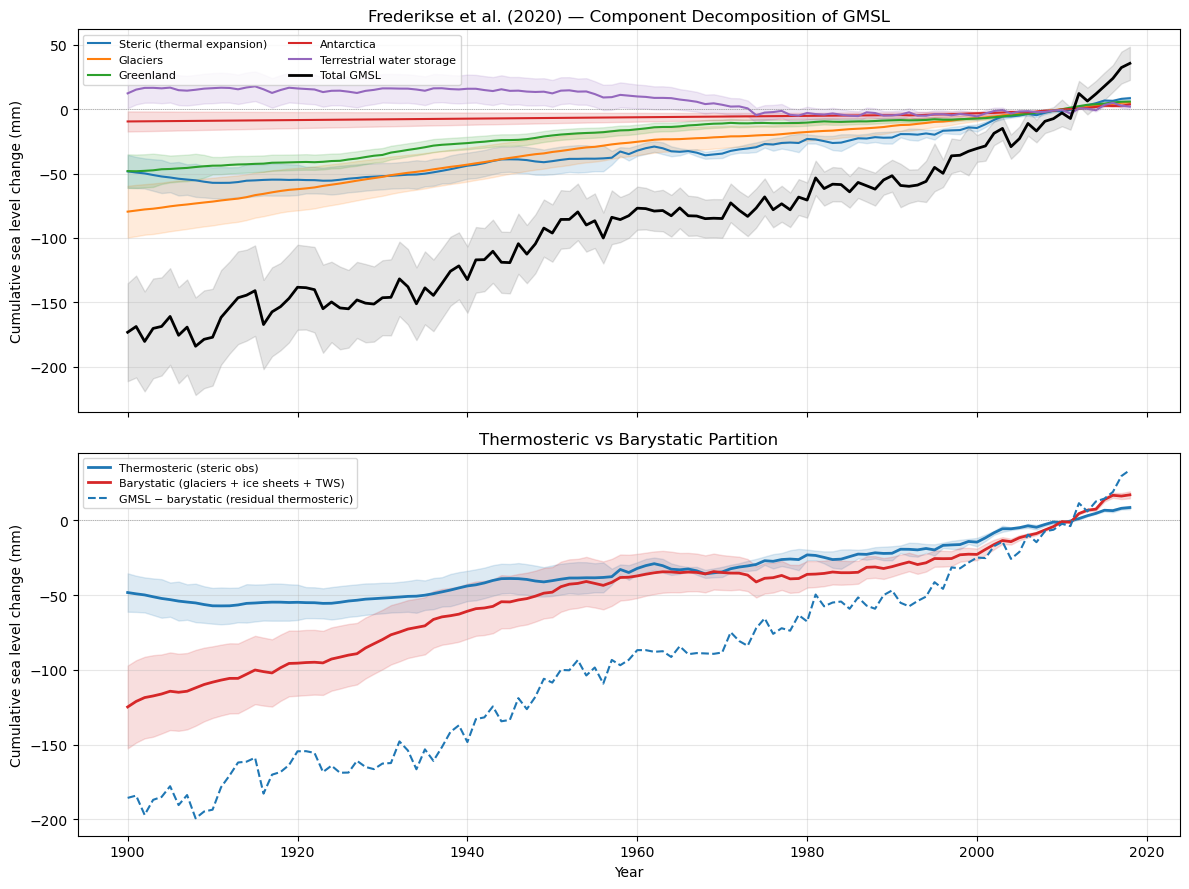

Saved: component_frederikse_overview.png


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# ── Panel A: Cumulative component contributions ──
ax = axes[0]
components = [
    ('Steric (thermal expansion)', fred_steric, fred_steric_sigma, 'C0'),
    ('Glaciers', fred_glaciers, fred_glaciers_sigma, 'C1'),
    ('Greenland', fred_greenland, fred_greenland_sigma, 'C2'),
    ('Antarctica', fred_antarctica, fred_antarctica_sigma, 'C3'),
    ('Terrestrial water storage', fred_tws, fred_tws_sigma, 'C4'),
]

for label, val, sig, color in components:
    ax.plot(fred_year, val * M_TO_MM, color=color, label=label)
    ax.fill_between(fred_year,
                    (val - 2*sig) * M_TO_MM,
                    (val + 2*sig) * M_TO_MM,
                    color=color, alpha=0.15)

ax.plot(fred_year, fred_gmsl * M_TO_MM, 'k-', lw=2, label='Total GMSL')
ax.fill_between(fred_year,
                (fred_gmsl - 2*fred_gmsl_sigma) * M_TO_MM,
                (fred_gmsl + 2*fred_gmsl_sigma) * M_TO_MM,
                color='k', alpha=0.1)

ax.set_ylabel('Cumulative sea level change (mm)')
ax.set_title('Frederikse et al. (2020) — Component Decomposition of GMSL')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.axhline(0, color='gray', ls=':', lw=0.5)
ax.grid(True, alpha=0.3)

# ── Panel B: Steric vs cryospheric residual ──
ax = axes[1]
# Cryospheric + TWS = barystatic
ax.plot(fred_year, fred_steric * M_TO_MM, 'C0-', lw=2,
        label='Thermosteric (steric obs)')
ax.fill_between(fred_year,
                (fred_steric - 2*fred_steric_sigma) * M_TO_MM,
                (fred_steric + 2*fred_steric_sigma) * M_TO_MM,
                color='C0', alpha=0.15)

ax.plot(fred_year, fred_barystatic * M_TO_MM, 'C3-', lw=2,
        label='Barystatic (glaciers + ice sheets + TWS)')
ax.fill_between(fred_year,
                (fred_barystatic - 2*fred_barystatic_sigma) * M_TO_MM,
                (fred_barystatic + 2*fred_barystatic_sigma) * M_TO_MM,
                color='C3', alpha=0.15)

ax.plot(fred_year, fred_thermo_gmsl * M_TO_MM, 'C0--', lw=1.5,
        label='GMSL − barystatic (residual thermosteric)')

ax.set_ylabel('Cumulative sea level change (mm)')
ax.set_xlabel('Year')
ax.set_title('Thermosteric vs Barystatic Partition')
ax.legend(loc='upper left', fontsize=8)
ax.axhline(0, color='gray', ls=':', lw=0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_frederikse_overview.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Saved: component_frederikse_overview.png')

## 3. Stage 1: Bayesian Thermosteric Calibration

Fit the rate–temperature model to the **steric component only**:

$$\text{rate}_{\text{thermo}}(t) = a_{\text{th}} \cdot T(t)^2 + b_{\text{th}} \cdot T(t) + c_{\text{th}}$$

**Expected physics:** Thermal expansion is approximately linear in GMST
(the thermal expansion coefficient varies slowly). Therefore:
- PC (Exponential) prior on $a_{\text{th}}$ → expect near zero
- $b_{\text{th}}$ dominates the temperature sensitivity
- $c_{\text{th}}$ captures any residual trend

In [5]:
# ── Rebase steric to 2005 baseline ──
# Find index closest to BASELINE_YEAR
baseline_mask = (fred_year >= 1995) & (fred_year <= 2015)
baseline_idx = np.argmin(np.abs(fred_year - BASELINE_YEAR))

steric_rebase = fred_steric - fred_steric[baseline_idx]
steric_sigma = fred_steric_sigma.copy()

gmsl_rebase = fred_gmsl - fred_gmsl[baseline_idx]
gmsl_sigma = fred_gmsl_sigma.copy()

print(f'Baseline: {fred_year[baseline_idx]:.0f}')
print(f'Steric at baseline: {fred_steric[baseline_idx]*M_TO_MM:.2f} mm (set to 0)')
print(f'GMSL at baseline: {fred_gmsl[baseline_idx]*M_TO_MM:.2f} mm (set to 0)')

Baseline: 2005
Steric at baseline: -4.91 mm (set to 0)
GMSL at baseline: -22.83 mm (set to 0)


In [6]:
# ── Build design vectors using monthly temperature ──
design = build_level_design_vectors(
    temperature_monthly=temp_monthly,
    time_monthly=temp_time_monthly,
    obs_times=fred_year,
)

I2_obs = design['I2_obs']
I1_obs = design['I1_obs']
I0_obs = design['I0_obs']

print(f'Design vectors computed: {len(I2_obs)} observation times')
print(f'  I2 range: [{I2_obs.min():.4f}, {I2_obs.max():.4f}]')
print(f'  I1 range: [{I1_obs.min():.4f}, {I1_obs.max():.4f}]')
print(f'  I0 range: [{I0_obs.min():.4f}, {I0_obs.max():.4f}]')

Design vectors computed: 119 observation times
  I2 range: [40.1106, 85.1442]
  I1 range: [-103.7137, -43.6910]
  I0 range: [49.9167, 167.9167]


In [7]:
# ── Prior configuration for thermosteric ──
#
# Key insight: thermal expansion is nearly linear in T.
# PC prior on a_th strongly shrinks toward a_th = 0.
#
# For steric, the coefficient magnitudes are SMALLER than for total GMSL
# because steric accounts for only ~25-30% of total SLR.

# Exponential PC prior on a_th: P(a_th > 2 mm/yr/°C²) = 10%
# (steric alone should have much smaller a than total GMSL)
PRIOR_SCALE_A_THERMO = calibrate_exponential_prior(
    prob_exceed=0.10, threshold=0.002    # 2 mm/yr/°C² threshold
)

# b_th ~ HalfNormal: steric sensitivity ~1-2 mm/yr/°C
PRIOR_SCALE_B_THERMO = 0.005   # 5 mm/yr/°C (generous)

# c_th ~ Normal: small background trend
PRIOR_C_MEAN_THERMO = 0.0005   # 0.5 mm/yr
PRIOR_C_SIGMA_THERMO = 0.002   # 2 mm/yr

# σ_extra: model inadequacy for steric (should be small)
PRIOR_SIGMA_EXTRA_THERMO = 0.002  # 2 mm

# H0: offset uncertainty
PRIOR_H0_SIGMA_THERMO = 0.010  # 10 mm

print('Thermosteric prior configuration:')
print(f'  a_th ~ Exp(mean = {PRIOR_SCALE_A_THERMO*M_TO_MM:.2f} mm/yr/°C²)')
print(f'    → P(a_th > 2 mm/yr/°C²) = 10%')
print(f'  b_th ~ HN(σ = {PRIOR_SCALE_B_THERMO*M_TO_MM:.1f} mm/yr/°C)')
print(f'  c_th ~ N({PRIOR_C_MEAN_THERMO*M_TO_MM:.1f}, '
      f'{PRIOR_C_SIGMA_THERMO*M_TO_MM:.1f} mm/yr)')
print(f'  σ_extra ~ HC({PRIOR_SIGMA_EXTRA_THERMO*M_TO_MM:.1f} mm)')
print(f'  H₀ ~ N(obs, {PRIOR_H0_SIGMA_THERMO*M_TO_MM:.0f} mm)')

Thermosteric prior configuration:
  a_th ~ Exp(mean = 0.87 mm/yr/°C²)
    → P(a_th > 2 mm/yr/°C²) = 10%
  b_th ~ HN(σ = 5.0 mm/yr/°C)
  c_th ~ N(0.5, 2.0 mm/yr)
  σ_extra ~ HC(2.0 mm)
  H₀ ~ N(obs, 10 mm)


In [8]:
# ── Fit Bayesian level-space model to STERIC component ──
result_thermo = fit_bayesian_level(
    H_obs=steric_rebase,
    sigma_obs=steric_sigma,
    I2_obs=I2_obs,
    I1_obs=I1_obs,
    I0_obs=I0_obs,
    prior_scale_a=PRIOR_SCALE_A_THERMO,
    prior_scale_b=PRIOR_SCALE_B_THERMO,
    prior_c_mean=PRIOR_C_MEAN_THERMO,
    prior_c_sigma=PRIOR_C_SIGMA_THERMO,
    prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_THERMO,
    prior_H0_sigma=PRIOR_H0_SIGMA_THERMO,
    n_samples=4000,
    n_walkers=32,
    n_burnin=2000,
    thin=2,
    seed=42,
)

Bayesian level-space fit: n=119 observations, ndim=5
  Priors: a~Exp(mean=0.87 mm/yr/°C²), b~HN(5.0 mm/yr/°C), c~N(0.5, 2.0 mm/yr), σ_extra~HC(2.0 mm)
  OLS init: a=-0.233, b=0.676, c=0.950 mm/yr, σ_extra=2.50 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:07<00:00, 816.54it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.010  ESS_bulk=303  ESS_tail=937
    alpha0: R-hat=1.006  ESS_bulk=288  ESS_tail=714
    trend: R-hat=1.014  ESS_bulk=255  ESS_tail=701
    log_sigma_extra: R-hat=1.019  ESS_bulk=266  ESS_tail=785
    H0: R-hat=1.015  ESS_bulk=299  ESS_tail=681
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.259, b=1.112, c=0.989 mm/yr
  σ_extra: median=1.13 mm [0.77, 1.57]
  R² = 0.9794,  acceptance = 0.53


In [9]:
# ── Report thermosteric calibration results ──
# BayesianLevelResult stores: posterior_samples (n, 3) = [a, b, c],
#   H0_posterior (n,), sigma_extra_posterior (n,)
a_th = result_thermo.posterior_samples[:, 0]
b_th = result_thermo.posterior_samples[:, 1]
c_th = result_thermo.posterior_samples[:, 2]
sigma_extra_th = result_thermo.sigma_extra_posterior
H0_th = result_thermo.H0_posterior

print('='*65)
print('THERMOSTERIC CALIBRATION RESULTS')
print('='*65)

for name, s, unit in [
    ('a_th', a_th * M_TO_MM, 'mm/yr/°C²'),
    ('b_th', b_th * M_TO_MM, 'mm/yr/°C'),
    ('c_th', c_th * M_TO_MM, 'mm/yr'),
    ('σ_extra', sigma_extra_th * M_TO_MM, 'mm'),
    ('H₀', H0_th * M_TO_MM, 'mm'),
]:
    p5, med, p95 = np.percentile(s, [5, 50, 95])
    print(f'  {name:12s} = {med:7.3f} [{p5:.3f}, {p95:.3f}] {unit}')

# R² for steric fit
H_model = np.median(a_th) * I2_obs + np.median(b_th) * I1_obs + \
          np.median(c_th) * I0_obs + np.median(H0_th)
ss_res = np.sum((steric_rebase - H_model)**2)
ss_tot = np.sum((steric_rebase - np.mean(steric_rebase))**2)
r2_thermo = 1 - ss_res / ss_tot
print(f'\n  R² = {r2_thermo:.4f}')
print(f'  P(a_th < 0.5 mm/yr/°C²) = '
      f'{np.mean(a_th * M_TO_MM < 0.5):.1%}')
print('='*65)

THERMOSTERIC CALIBRATION RESULTS
  a_th         =   0.243 [0.032, 0.546] mm/yr/°C²
  b_th         =   1.101 [0.938, 1.322] mm/yr/°C
  c_th         =   0.989 [0.957, 1.020] mm/yr
  σ_extra      =   1.127 [0.814, 1.511] mm
  H₀           = -61.278 [-67.528, -55.721] mm

  R² = 0.9797
  P(a_th < 0.5 mm/yr/°C²) = 92.1%


## 4. Comparison: Total GMSL vs Thermosteric

Fit the same Bayesian level-space model to the **total GMSL** and compare
coefficients. The difference reveals how much of the quadratic acceleration
comes from steric vs cryospheric sources.

In [10]:
# ── Fit to TOTAL GMSL for comparison ──
# Use same priors as the predictability analysis (wider for total)
PRIOR_SCALE_A_TOTAL = calibrate_exponential_prior(
    prob_exceed=0.10, threshold=0.005    # 5 mm/yr/°C²
)

result_total = fit_bayesian_level(
    H_obs=gmsl_rebase,
    sigma_obs=gmsl_sigma,
    I2_obs=I2_obs,
    I1_obs=I1_obs,
    I0_obs=I0_obs,
    prior_scale_a=PRIOR_SCALE_A_TOTAL,
    prior_scale_b=0.010,
    prior_c_mean=0.002,
    prior_c_sigma=0.005,
    prior_sigma_extra_scale=0.005,
    prior_H0_sigma=0.050,
    n_samples=4000,
    n_walkers=32,
    n_burnin=2000,
    thin=2,
    seed=43,
)

Bayesian level-space fit: n=119 observations, ndim=5
  Priors: a~Exp(mean=2.17 mm/yr/°C²), b~HN(10.0 mm/yr/°C), c~N(2.0, 5.0 mm/yr), σ_extra~HC(5.0 mm)
  OLS init: a=3.118, b=3.896, c=2.476 mm/yr, σ_extra=9.31 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:07<00:00, 778.39it/s]

  Convergence diagnostics:
    dalpha_dT: R-hat=1.016  ESS_bulk=247  ESS_tail=700
    alpha0: R-hat=1.018  ESS_bulk=245  ESS_tail=791
    trend: R-hat=1.012  ESS_bulk=289  ESS_tail=640
    log_sigma_extra: R-hat=1.017  ESS_bulk=209  ESS_tail=311
    H0: R-hat=1.007  ESS_bulk=294  ESS_tail=564
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=4.476, b=5.005, c=2.535 mm/yr
  σ_extra: median=1.70 mm [0.11, 4.07]
  R² = 0.9696,  acceptance = 0.54


In [11]:
# ── Coefficient comparison: total vs thermosteric ──
a_total = result_total.posterior_samples[:, 0]
b_total = result_total.posterior_samples[:, 1]
c_total = result_total.posterior_samples[:, 2]

print('COEFFICIENT COMPARISON (median [5%, 95%] in mm/yr units)')
print('='*70)
print(f'{"Parameter":15s} {"Total GMSL":>22s}   {"Thermosteric":>22s}   {"Cryo residual":>22s}')
print('-'*70)

for name, st, sth in [
    ('a (dα/dT)', a_total * M_TO_MM, a_th * M_TO_MM),
    ('b (α₀)',    b_total * M_TO_MM, b_th * M_TO_MM),
    ('c (trend)', c_total * M_TO_MM, c_th * M_TO_MM),
]:
    mt = np.median(st)
    mth = np.median(sth)
    # Residual = total - thermo (approximate, not from joint fit)
    n_min = min(len(st), len(sth))
    resid = st[:n_min] - sth[:n_min]
    mr = np.median(resid)
    print(f'  {name:13s} '
          f'{mt:6.3f} [{np.percentile(st,5):6.3f}, {np.percentile(st,95):6.3f}]   '
          f'{mth:6.3f} [{np.percentile(sth,5):6.3f}, {np.percentile(sth,95):6.3f}]   '
          f'{mr:6.3f} [{np.percentile(resid,5):6.3f}, {np.percentile(resid,95):6.3f}]')

print('='*70)
print('\nNote: residual coefficients approximate the combined cryospheric + TWS')
print('contribution.  These will be refined in Stages 2–4.')

COEFFICIENT COMPARISON (median [5%, 95%] in mm/yr units)
Parameter                   Total GMSL             Thermosteric            Cryo residual
----------------------------------------------------------------------
  a (dα/dT)      4.488 [ 3.178,  5.746]    0.243 [ 0.032,  0.546]    4.228 [ 2.888,  5.519]
  b (α₀)         5.011 [ 4.033,  5.955]    1.101 [ 0.938,  1.322]    3.898 [ 2.904,  4.861]
  c (trend)      2.536 [ 2.404,  2.665]    0.989 [ 0.957,  1.020]    1.547 [ 1.412,  1.678]

Note: residual coefficients approximate the combined cryospheric + TWS
contribution.  These will be refined in Stages 2–4.


## 5. Model Fit Visualization

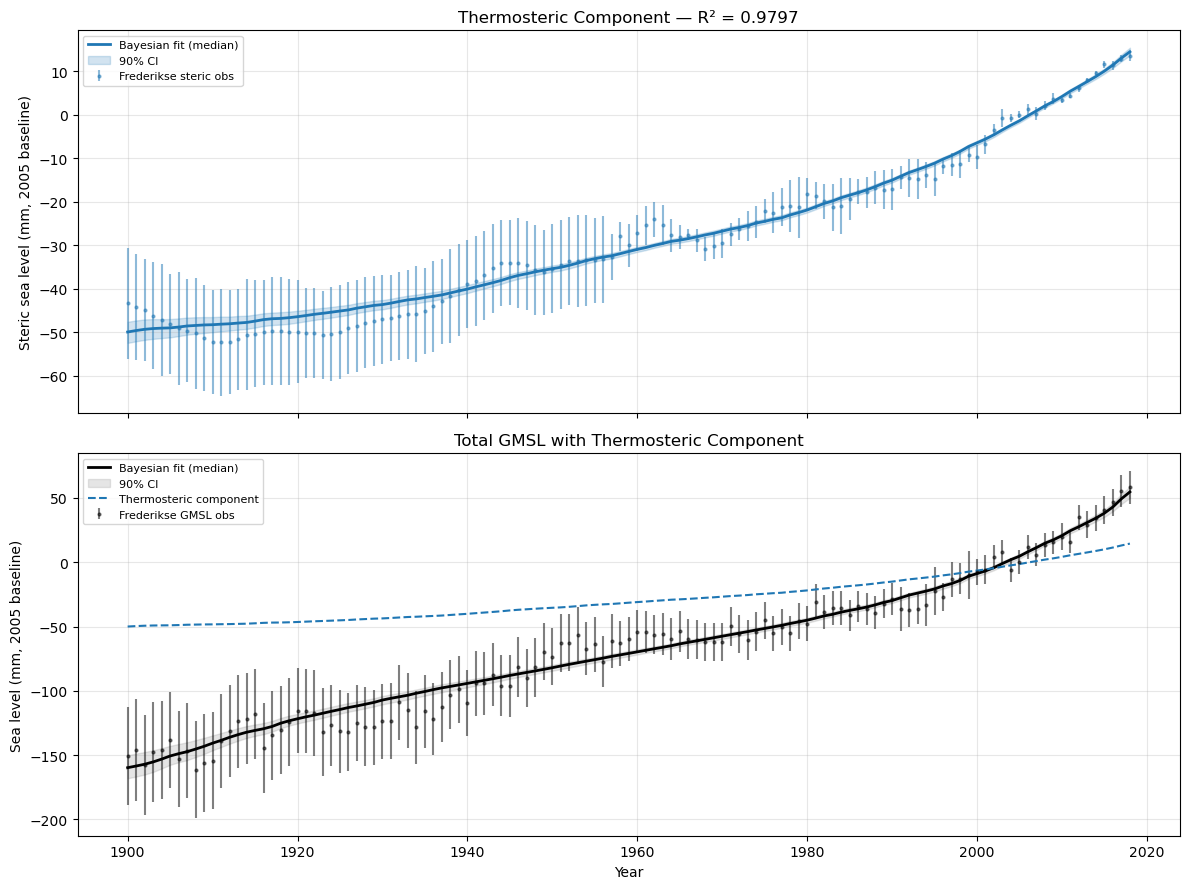

Saved: component_stage1_fit.png


In [12]:
# ── Plot: Model fits to steric and total GMSL ──
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# Helper: compute model prediction ensemble from BayesianLevelResult
def model_ensemble(result, I2, I1, I0, n_draw=500):
    """Draw n_draw random model predictions from posterior."""
    n_avail = len(result.posterior_samples)
    n_draw = min(n_draw, n_avail)
    idx = np.random.choice(n_avail, n_draw, replace=False)
    H_ens = np.zeros((n_draw, len(I2)))
    for i, j in enumerate(idx):
        a = result.posterior_samples[j, 0]
        b = result.posterior_samples[j, 1]
        c = result.posterior_samples[j, 2]
        H0 = result.H0_posterior[j]
        H_ens[i] = a * I2 + b * I1 + c * I0 + H0
    return H_ens

# Panel A: Thermosteric
ax = axes[0]
ax.errorbar(fred_year, steric_rebase * M_TO_MM,
            yerr=2*steric_sigma * M_TO_MM,
            fmt='o', ms=2, color='C0', alpha=0.5, label='Frederikse steric obs')

H_ens_th = model_ensemble(result_thermo, I2_obs, I1_obs, I0_obs)
p5, p50, p95 = np.percentile(H_ens_th * M_TO_MM, [5, 50, 95], axis=0)
ax.plot(fred_year, p50, 'C0-', lw=2, label='Bayesian fit (median)')
ax.fill_between(fred_year, p5, p95, color='C0', alpha=0.2, label='90% CI')

ax.set_ylabel('Steric sea level (mm, 2005 baseline)')
ax.set_title(f'Thermosteric Component — R² = {r2_thermo:.4f}')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

# Panel B: Total GMSL
ax = axes[1]
ax.errorbar(fred_year, gmsl_rebase * M_TO_MM,
            yerr=2*gmsl_sigma * M_TO_MM,
            fmt='o', ms=2, color='k', alpha=0.5, label='Frederikse GMSL obs')

H_ens_tot = model_ensemble(result_total, I2_obs, I1_obs, I0_obs)
p5t, p50t, p95t = np.percentile(H_ens_tot * M_TO_MM, [5, 50, 95], axis=0)
ax.plot(fred_year, p50t, 'k-', lw=2, label='Bayesian fit (median)')
ax.fill_between(fred_year, p5t, p95t, color='gray', alpha=0.2, label='90% CI')

# Overlay thermosteric component
ax.plot(fred_year, p50, 'C0--', lw=1.5, label='Thermosteric component')

ax.set_ylabel('Sea level (mm, 2005 baseline)')
ax.set_xlabel('Year')
ax.set_title('Total GMSL with Thermosteric Component')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_stage1_fit.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Saved: component_stage1_fit.png')

## 6. Cryospheric + TWS Residual

The cryospheric residual is the observed GMSL minus the fitted
thermosteric component. This represents the combined contribution of
glaciers + Greenland + Antarctica + TWS.

We validate this residual against direct observations from IMBIE
(ice sheets) and GlaMBIE (glaciers) over their respective periods.

In [13]:
# ── Compute cryospheric residual ──
# Method 1: From Frederikse directly (barystatic = sum of mass terms)
barystatic_rebase = fred_barystatic - fred_barystatic[baseline_idx]

# Method 2: GMSL minus fitted thermosteric model
H_thermo_median = np.median(a_th) * I2_obs + np.median(b_th) * I1_obs + \
                  np.median(c_th) * I0_obs + np.median(H0_th)
resid_model = gmsl_rebase - H_thermo_median

# Uncertainty on residual: quadrature of GMSL and thermo uncertainties
# (approximate — proper way is from the joint posterior)
resid_sigma = np.sqrt(gmsl_sigma**2 + steric_sigma**2)

print('Cryospheric + TWS residual at 2018:')
print(f'  Frederikse barystatic:     {barystatic_rebase[-1]*M_TO_MM:6.1f} mm')
print(f'  GMSL − fitted thermo:      {resid_model[-1]*M_TO_MM:6.1f} mm')
print(f'  Difference:                {(barystatic_rebase[-1]-resid_model[-1])*M_TO_MM:6.1f} mm')

Cryospheric + TWS residual at 2018:
  Frederikse barystatic:       28.7 mm
  GMSL − fitted thermo:        44.0 mm
  Difference:                 -15.3 mm


In [14]:
# ── Load independent validation data ──
# IMBIE ice sheets (1992-2020) — all from Gt-format CSV
# Convention: IMBIE cumulative_mass_balance is negative for mass loss.
#   For SLR contribution, negate: -cumul = positive sea level rise.
df_gris  = read_imbie_greenland(f'{RAW_DIR}/ice_sheets/Gt/imbie_greenland_2021_Gt.csv')
df_eais  = read_imbie_east_antarctica(f'{RAW_DIR}/ice_sheets/Gt/imbie_east_antarctica_2021_Gt.csv')
df_pen   = read_imbie_antarctic_peninsula(f'{RAW_DIR}/ice_sheets/Gt/imbie_antarctic_peninsula_2021_Gt.csv')
df_ais   = read_imbie_antarctica(f'{RAW_DIR}/ice_sheets/Gt/imbie_antarctica_2021_Gt.csv')
df_all_ice = read_imbie_all(f'{RAW_DIR}/ice_sheets/Gt/imbie_all_2021_Gt.csv')

# GlaMBIE glaciers (2000-2023) — reader already flips sign: positive = SLR
df_glac  = read_glambie_global(f'{RAW_DIR}/glaciers/0_global_glambie_consensus.csv')

# Annualize IMBIE to get cumulative curves
print('IMBIE ice sheet summary (SLR contribution at end of record):')
for df_ice, label in [(df_gris, 'GrIS'), (df_ais, 'AIS'),
                      (df_eais, 'EAIS'), (df_pen, 'Peninsula'),
                      (df_all_ice, 'All ice sheets')]:
    cum_yr = df_ice['cumulative_mass_balance'].resample('YE').last()
    # Negate: negative mass balance → positive SLR contribution
    slr_mm = -cum_yr.iloc[-1] * M_TO_MM
    print(f'  {label:16s}: {cum_yr.index[0].year}–{cum_yr.index[-1].year}, '
          f'SLR = {slr_mm:.1f} mm')

# GlaMBIE: cumulative mass loss (mass_balance is annual SLR rate in m/yr)
glac_cumul = np.cumsum(df_glac['mass_balance'].values)
print(f'  {"Glaciers (GlaMBIE)":16s}: 2000–2023, '
      f'SLR = {glac_cumul[-1]*M_TO_MM:.1f} mm')

IMBIE ice sheet summary (SLR contribution at end of record):
  GrIS            : 1992–2020, SLR = 13.5 mm
  AIS             : 1992–2020, SLR = 7.4 mm
  EAIS            : 1992–2020, SLR = -0.2 mm
  Peninsula       : 1992–2020, SLR = 1.0 mm
  All ice sheets  : 1992–2020, SLR = 20.9 mm
  Glaciers (GlaMBIE): 2000–2023, SLR = 18.0 mm


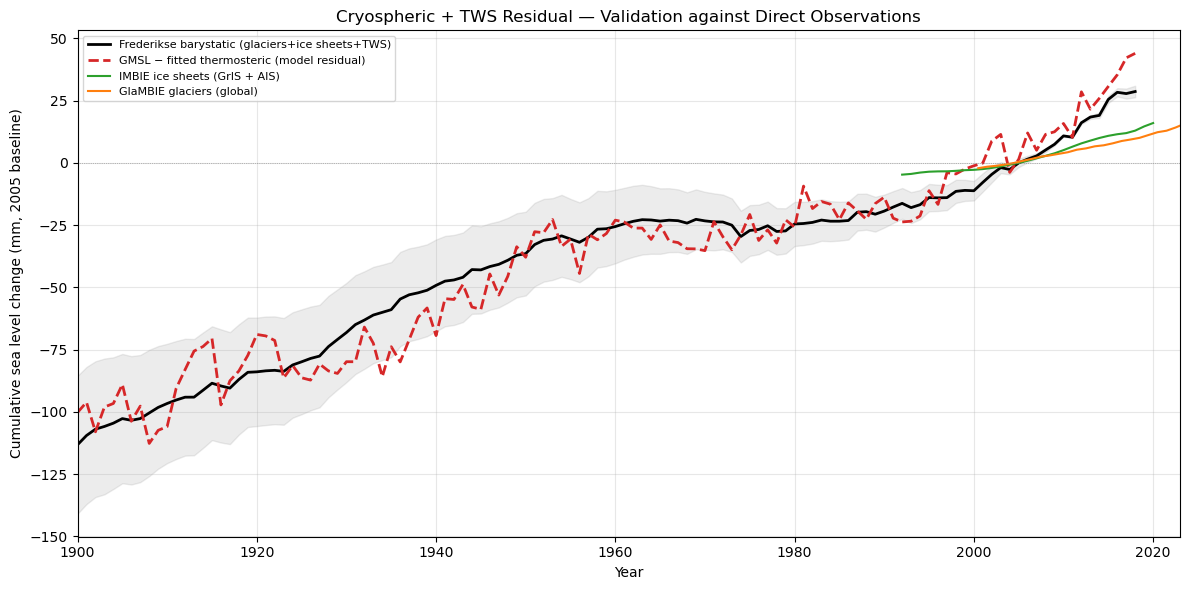

Saved: component_stage1_residual.png


In [15]:
# ── Validation figure: Residual vs direct observations ──
fig, ax = plt.subplots(figsize=(12, 6))

# Frederikse barystatic (positive = SLR contribution)
ax.plot(fred_year, barystatic_rebase * M_TO_MM, 'k-', lw=2,
        label='Frederikse barystatic (glaciers+ice sheets+TWS)')
ax.fill_between(fred_year,
                (barystatic_rebase - 2*fred_barystatic_sigma) * M_TO_MM,
                (barystatic_rebase + 2*fred_barystatic_sigma) * M_TO_MM,
                color='gray', alpha=0.15)

# GMSL - fitted thermo (model-based residual)
ax.plot(fred_year, resid_model * M_TO_MM, 'C3--', lw=2,
        label='GMSL − fitted thermosteric (model residual)')

# IMBIE: GrIS + AIS → SLR contribution = -cumulative_mass_balance
gris_yr = df_gris['cumulative_mass_balance'].resample('YE').last()
ais_yr = df_ais['cumulative_mass_balance'].resample('YE').last()
ice_years = gris_yr.index.year
# Negate to get SLR contribution (positive = sea level rise)
gris_slr = -gris_yr.values
ais_slr = -ais_yr.values
# Rebase to 2005
idx_2005 = np.argmin(np.abs(ice_years - 2005))
ice_slr = (gris_slr + ais_slr) - (gris_slr[idx_2005] + ais_slr[idx_2005])
ax.plot(ice_years, ice_slr * M_TO_MM, 'C2-', lw=1.5,
        label='IMBIE ice sheets (GrIS + AIS)')

# GlaMBIE cumulative (already positive = SLR contribution)
glac_years = df_glac['decimal_year'].values
glac_cumul_mm = np.cumsum(df_glac['mass_balance'].values) * M_TO_MM
# Rebase so ~2005 = 0
idx_2005_gl = np.argmin(np.abs(glac_years - 2005))
glac_cumul_mm -= glac_cumul_mm[idx_2005_gl]
ax.plot(glac_years, glac_cumul_mm, 'C1-', lw=1.5,
        label='GlaMBIE glaciers (global)')

ax.set_ylabel('Cumulative sea level change (mm, 2005 baseline)')
ax.set_xlabel('Year')
ax.set_title('Cryospheric + TWS Residual — Validation against Direct Observations')
ax.legend(loc='upper left', fontsize=8)
ax.axhline(0, color='gray', ls=':', lw=0.5)
ax.grid(True, alpha=0.3)
ax.set_xlim(1900, 2023)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_stage1_residual.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Saved: component_stage1_residual.png')

## 7. Thermosteric Projections

Project the thermosteric component under SSP scenarios using the
calibrated Bayesian posterior. Compare with IPCC AR6 ocean dynamics
projections.

In [16]:
# ── Configure projection settings ──
ssps_to_plot = ['SSP1-2.6', 'SSP2-4.5', 'SSP5-8.5']
ssp_colors = {'SSP1-2.6': 'C0', 'SSP2-4.5': 'C1', 'SSP5-8.5': 'C3'}

print(f'Will project for: {ssps_to_plot}')
for ssp in ssps_to_plot:
    if ssp in ipcc_temp_proj:
        df_ssp = ipcc_temp_proj[ssp]
        print(f'  {ssp}: T(2020)={df_ssp.loc[df_ssp["decimal_year"]==2020.0, "temperature"].values[0]:.2f}°C, '
              f'T(2099)={df_ssp["temperature"].iloc[-1]:.2f}°C')

Will project for: ['SSP1-2.6', 'SSP2-4.5', 'SSP5-8.5']
  SSP1-2.6: T(2020)=1.23°C, T(2099)=1.72°C
  SSP2-4.5: T(2020)=1.23°C, T(2099)=2.75°C
  SSP5-8.5: T(2020)=1.25°C, T(2099)=4.73°C


In [17]:
# ── Project thermosteric component under each SSP ──
# Use the posterior samples to propagate uncertainty

proj_years = np.arange(2020, 2101)
N_MC = min(len(a_th), 2000)
rng_proj = np.random.default_rng(44)
mc_idx = rng_proj.choice(len(a_th), N_MC, replace=False)

thermo_projections = {}  # ssp → dict with arrays

for ssp in ssps_to_plot:
    if ssp not in ipcc_temp_proj:
        print(f'  WARNING: No temperature projection found for {ssp}')
        continue
    
    df_ssp = ipcc_temp_proj[ssp]
    ipcc_years_float = df_ssp['decimal_year'].values
    ipcc_temp_vals = df_ssp['temperature'].values
    
    print(f'  {ssp}: T range [{ipcc_temp_vals.min():.2f}, {ipcc_temp_vals.max():.2f}] °C')
    
    # Build monthly temperature: historical + projected
    # Historical part: observed monthly up to ~2020
    hist_mask = temp_time_monthly <= 2020.0
    t_hist = temp_time_monthly[hist_mask]
    T_hist = temp_monthly[hist_mask]
    
    # Projected part: interpolate IPCC annual to monthly
    t_future = np.arange(2020.0 + 1/24, 2101.0, 1/12)
    T_future = np.interp(t_future, ipcc_years_float, ipcc_temp_vals)
    
    # Concatenate
    t_full = np.concatenate([t_hist, t_future])
    T_full = np.concatenate([T_hist, T_future])
    
    # Build design vectors on full grid
    dv_proj = build_level_design_vectors(
        temperature_monthly=T_full,
        time_monthly=t_full,
        obs_times=np.concatenate([fred_year, proj_years.astype(float)]),
    )
    
    # Extract projection-era design vectors
    n_obs = len(fred_year)
    I2_proj = dv_proj['I2_obs'][n_obs:]
    I1_proj = dv_proj['I1_obs'][n_obs:]
    I0_proj = dv_proj['I0_obs'][n_obs:]
    
    # MC ensemble
    thermo_ens = np.zeros((N_MC, len(proj_years)))
    for i, j in enumerate(mc_idx):
        thermo_ens[i] = (a_th[j] * I2_proj + b_th[j] * I1_proj +
                         c_th[j] * I0_proj + H0_th[j])
    
    thermo_projections[ssp] = {
        'years': proj_years,
        'samples': thermo_ens,
        'median': np.median(thermo_ens, axis=0),
        'p5': np.percentile(thermo_ens, 5, axis=0),
        'p95': np.percentile(thermo_ens, 95, axis=0),
        'temperature': T_future,
    }
    
    val_2100 = thermo_projections[ssp]['median'][-1]
    print(f'    Thermosteric at 2100: '
          f'{val_2100*M_TO_MM:.0f} mm '
          f'[{thermo_projections[ssp]["p5"][-1]*M_TO_MM:.0f}, '
          f'{thermo_projections[ssp]["p95"][-1]*M_TO_MM:.0f}]')

  SSP1-2.6: T range [1.10, 1.80] °C
    Thermosteric at 2100: 300 mm [231, 391]
  SSP2-4.5: T range [1.10, 2.75] °C
    Thermosteric at 2100: 371 mm [269, 511]
  SSP5-8.5: T range [1.11, 4.73] °C
    Thermosteric at 2100: 531 mm [341, 792]


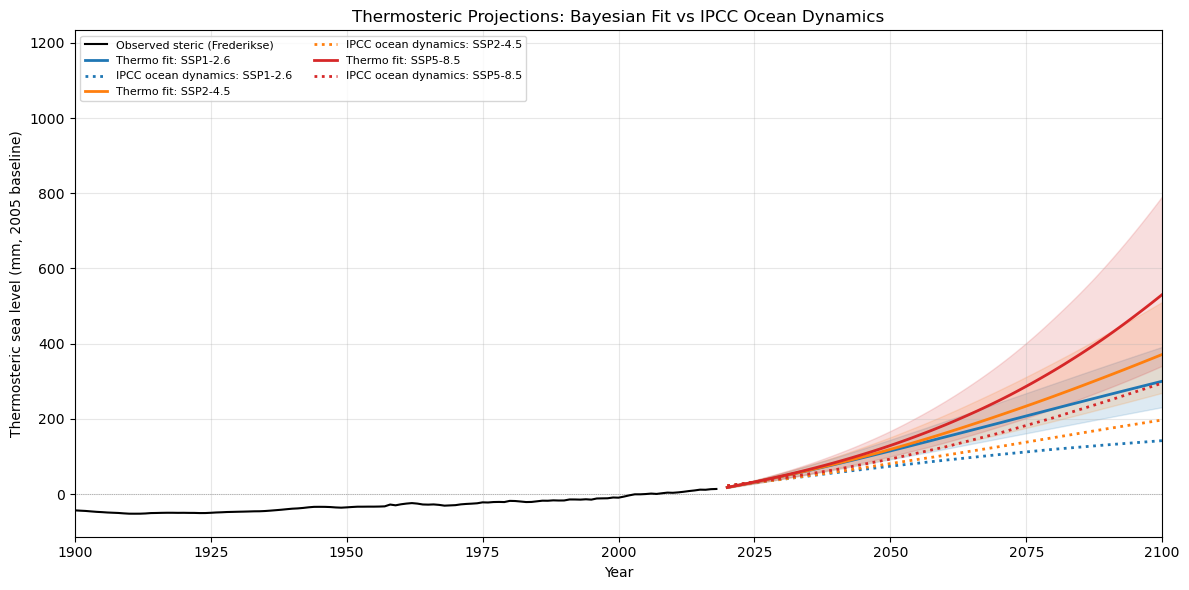

Saved: component_stage1_projections.png


In [18]:
# ── Comparison with IPCC ocean dynamics projections ──
fig, ax = plt.subplots(figsize=(12, 6))

# Historical steric
ax.plot(fred_year, steric_rebase * M_TO_MM, 'k-', lw=1.5,
        label='Observed steric (Frederikse)', zorder=5)

for ssp in ssps_to_plot:
    if ssp not in thermo_projections:
        continue
    proj = thermo_projections[ssp]
    color = ssp_colors[ssp]
    
    # Our thermosteric projection
    ax.plot(proj['years'], proj['median'] * M_TO_MM,
            color=color, lw=2, label=f'Thermo fit: {ssp}')
    ax.fill_between(proj['years'],
                    proj['p5'] * M_TO_MM,
                    proj['p95'] * M_TO_MM,
                    color=color, alpha=0.15)
    
    # IPCC ocean dynamics
    ssp_code = ssp.lower().replace('-', '').replace('.', '')
    try:
        df_ipcc_od = read_ipcc_ar6_component(
            COMP_DIR, 'oceandynamics', scenario=ssp_code
        )
        ax.plot(df_ipcc_od.index, df_ipcc_od['median'] * M_TO_MM,
                color=color, ls=':', lw=2,
                label=f'IPCC ocean dynamics: {ssp}')
    except FileNotFoundError:
        pass

ax.set_ylabel('Thermosteric sea level (mm, 2005 baseline)')
ax.set_xlabel('Year')
ax.set_title('Thermosteric Projections: Bayesian Fit vs IPCC Ocean Dynamics')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.axhline(0, color='gray', ls=':', lw=0.5)
ax.grid(True, alpha=0.3)
ax.set_xlim(1900, 2100)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_stage1_projections.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Saved: component_stage1_projections.png')

## Stage 1b: Physically-Motivated Thermosteric Model

The standard model above treats the rate of steric rise as an instantaneous function of GMST: rate = a·T² + b·T + c. This is phenomenological — the T² term has no direct physical derivation for thermal expansion.

**Physical motivation**: The thermal expansion coefficient α of seawater increases with temperature (TEOS-10: α ≈ α₀ + α₁·T). This means steric sea level is *quadratic in ocean temperature*:

$$\eta(t) \approx \frac{\alpha_1}{2} h_\mathrm{eff} \cdot T_\mathrm{ocean}^2 + \alpha_0 \, h_\mathrm{eff} \cdot T_\mathrm{ocean} + \text{const}$$

Furthermore, the ocean temperature *lags* GMST — the upper ocean equilibrates over ~5–25 years, the deep ocean over ~100–400 years (Geoffroy et al., 2013).

**Model**: We introduce a state variable $S_u(t)$ for effective ocean temperature:

$$\frac{dS_u}{dt} = \frac{T(t) - S_u(t)}{\tau_u}, \qquad \eta(t) = a \cdot S_u^2 + b \cdot S_u + c \cdot (t - t_0) + H_0$$

The **key structural difference** from Stage 1: the level depends on $S_u$ (not $\int \text{rate} \, dt$), and the quadratic enters via the physics of α(T), not as a rate polynomial. As $\tau_u \to 0$, $S_u \to T$ and this reduces to the instantaneous model.

In [ ]:
# ── Stage 1b: Fit physically-motivated thermosteric model (single-layer) ──
from bayesian_dols import fit_bayesian_thermosteric, solve_twolayer_ode

# Prior configuration — physics-informed from TEOS-10 and Geoffroy et al. (2013)
#
# a = (α₁/2)·h_eff  ~  thermal expansion curvature
#     α₁ ≈ 1×10⁻⁵ °C⁻²; h_eff ~ 200–500 m → a ~ 0.001–0.003 m/°C²
#     Exponential PC prior: P(a > 0.5 m/°C²) = 10% → μ_a ≈ 0.22 m/°C²
#
# b = α₀·h_u  ~  baseline expansion
#     α₀ ≈ 1.5×10⁻⁴ °C⁻¹ × h_u ~ 300m → b ~ 0.045 m/°C
#     HalfNormal(σ = 0.15 m/°C)
#
# τ_u ~ 5–25 yr (upper ocean): LogNormal(log(8), 0.5)
#   Geoffroy et al. (2013): fast component 4–25 yr, median ~8 yr
#   IPCC AR6 TLM ensemble: median 3.2 yr
#
# c ~ secular drift (halosteric + dynamics): Normal(0.3, 0.5 mm/yr)

result_phys = fit_bayesian_thermosteric(
    H_obs=steric_rebase,
    sigma_obs=steric_sigma,
    T_monthly=temp_monthly,
    time_monthly=temp_time_monthly,
    obs_times=fred_year,
    n_layers=1,
    # Priors
    prior_scale_a=0.22,          # Exponential mean (m/°C²)
    prior_scale_b=0.15,          # HalfNormal σ (m/°C)
    prior_c_mean=0.0003,         # Normal mean (m/yr) = 0.3 mm/yr
    prior_c_sigma=0.0005,        # Normal σ (m/yr) = 0.5 mm/yr
    prior_sigma_extra_scale=0.003,  # HalfCauchy γ (m)
    prior_H0_sigma=0.010,        # Normal σ on H₀ (m)
    # MCMC
    n_samples=5000,
    n_walkers=64,
    n_burnin=3000,
    thin=1,
    progress=True,
    seed=42,
)

# ── Posterior summary ──
print('\n' + '='*65)
print('STAGE 1b: PHYSICALLY-MOTIVATED THERMOSTERIC MODEL (1-layer)')
print('='*65)

a_phys = result_phys.posterior_samples[:, 0]
b_phys = result_phys.posterior_samples[:, 1]
c_phys = result_phys.posterior_samples[:, 2]
tau_u_phys = result_phys.tau_u_posterior

for name, s, unit in [
    ('a (expansion curvature)', a_phys, 'm/°C²'),
    ('b (baseline expansion)',  b_phys, 'm/°C'),
    ('c (secular drift)',       c_phys, 'm/yr'),
]:
    med = np.median(s)
    lo, hi = np.percentile(s, [3, 97])
    # Also show in mm units for readability
    scale = M_TO_MM if 'm/' in unit else 1.0
    print(f'  {name:30s}: {med:.5f} {unit}  '
          f'({med*scale:.3f} {unit.replace("m/","mm/")})'
          f'  94% HDI [{lo:.5f}, {hi:.5f}]')

print(f'\n  τ_u (upper ocean lag):   {np.median(tau_u_phys):.1f} yr  '
      f'[{np.percentile(tau_u_phys, 3):.1f}, {np.percentile(tau_u_phys, 97):.1f}]')
print(f'  σ_extra:                {np.median(result_phys.sigma_extra_posterior)*M_TO_MM:.2f} mm')
print(f'  H₀:                    {np.mean(result_phys.H0_posterior)*M_TO_MM:.2f} mm')
print(f'  R² = {result_phys.r2:.4f}')

# Physics diagnostic: a/b ratio vs TEOS-10
ab_ratio = a_phys / np.maximum(b_phys, 1e-8)
print(f'\n  a/b ratio:   {np.median(ab_ratio):.4f} °C⁻¹  '
      f'[{np.percentile(ab_ratio, 3):.4f}, {np.percentile(ab_ratio, 97):.4f}]')
print(f'  TEOS-10 expectation: α₁/(2α₀) ≈ 0.033 °C⁻¹')

# Comparison with Stage 1 instantaneous model
r2_thermo_s1 = r2_thermo if 'r2_thermo' in dir() else None
if r2_thermo_s1 is not None:
    print(f'\n  Stage 1 (instantaneous) R² = {r2_thermo_s1:.4f}')
    print(f'  Stage 1b (physical)     R² = {result_phys.r2:.4f}')
    print(f'  ΔR² = {result_phys.r2 - r2_thermo_s1:.4f}')

In [ ]:
# ── Stage 1b: Diagnostics ──
import arviz as az
from bayesian_dols import check_convergence

# Trace plots for key parameters
fig, axes = plt.subplots(2, 3, figsize=(15, 7))

# a
axes[0, 0].hist(a_phys * M_TO_MM, bins=60, density=True, alpha=0.7, color='C0')
axes[0, 0].set_xlabel('a (mm/°C²)')
axes[0, 0].set_title('Expansion curvature')
axes[0, 0].axvline(np.median(a_phys) * M_TO_MM, color='k', ls='--', lw=1.5)

# b
axes[0, 1].hist(b_phys * M_TO_MM, bins=60, density=True, alpha=0.7, color='C1')
axes[0, 1].set_xlabel('b (mm/°C)')
axes[0, 1].set_title('Baseline expansion')
axes[0, 1].axvline(np.median(b_phys) * M_TO_MM, color='k', ls='--', lw=1.5)

# c
axes[0, 2].hist(c_phys * M_TO_MM, bins=60, density=True, alpha=0.7, color='C2')
axes[0, 2].set_xlabel('c (mm/yr)')
axes[0, 2].set_title('Secular drift')
axes[0, 2].axvline(np.median(c_phys) * M_TO_MM, color='k', ls='--', lw=1.5)

# τ_u
axes[1, 0].hist(tau_u_phys, bins=60, density=True, alpha=0.7, color='C3')
axes[1, 0].set_xlabel('τ_u (yr)')
axes[1, 0].set_title('Upper ocean lag')
axes[1, 0].axvline(np.median(tau_u_phys), color='k', ls='--', lw=1.5)

# σ_extra
axes[1, 1].hist(result_phys.sigma_extra_posterior * M_TO_MM, bins=60,
                density=True, alpha=0.7, color='C4')
axes[1, 1].set_xlabel('σ_extra (mm)')
axes[1, 1].set_title('Model inadequacy')
axes[1, 1].axvline(np.median(result_phys.sigma_extra_posterior) * M_TO_MM,
                   color='k', ls='--', lw=1.5)

# a/b ratio vs TEOS-10
axes[1, 2].hist(ab_ratio, bins=60, density=True, alpha=0.7, color='C5')
axes[1, 2].axvline(0.033, color='r', ls='--', lw=2, label='TEOS-10: 0.033 °C⁻¹')
axes[1, 2].set_xlabel('a/b (°C⁻¹)')
axes[1, 2].set_title('a/b ratio (physics check)')
axes[1, 2].legend(fontsize=8)

fig.suptitle('Stage 1b: Posterior Distributions (Single-Layer Physical Model)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_stage1b_posteriors.png', dpi=150,
            bbox_inches='tight')
plt.show()

# ── Convergence report ──
print('\nConvergence diagnostics:')
conv = check_convergence(result_phys.trace, quiet=False)

# Acceptance fraction
if result_phys.sampler_diagnostics:
    print(f"Mean acceptance fraction: "
          f"{result_phys.sampler_diagnostics['acceptance_fraction']:.3f}")

In [ ]:
# ── Stage 1b: Ocean state variable S_u(t) vs surface temperature T(t) ──
# Show the thermal lag and committed warming

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Panel 1: T(t) and S_u(t)
ax1 = axes[0]
ax1.plot(temp_time_monthly, temp_monthly, 'C0-', lw=0.8, alpha=0.5,
         label='GMST T(t) (monthly)')

# Annual-mean temperature for cleaner comparison
annual_T = pd.Series(temp_monthly, index=temp_time_monthly).groupby(
    np.floor(temp_time_monthly)).mean()
ax1.plot(annual_T.index, annual_T.values, 'C0-', lw=1.5,
         label='GMST T(t) (annual mean)')

# S_u at posterior median τ_u
ax1.plot(temp_time_monthly, result_phys.S_u_mean, 'C3-', lw=2,
         label=f'Ocean state S_u(t)  [τ_u = {np.median(tau_u_phys):.1f} yr]')

ax1.set_ylabel('Temperature anomaly (°C)')
ax1.set_title('Surface Temperature vs Effective Ocean Temperature')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# Shade the lag visually for recent period
recent = (temp_time_monthly >= 1970) & (temp_time_monthly <= 2020)
ax1.fill_between(temp_time_monthly[recent],
                 result_phys.S_u_mean[recent],
                 np.interp(temp_time_monthly[recent],
                           annual_T.index, annual_T.values),
                 alpha=0.15, color='C3', label='_nolegend_')

# Panel 2: Lag = T - S_u (committed ocean warming)
ax2 = axes[1]
lag = temp_monthly - result_phys.S_u_mean
# Smooth for visualization
lag_annual = pd.Series(lag, index=temp_time_monthly).groupby(
    np.floor(temp_time_monthly)).mean()

ax2.plot(lag_annual.index, lag_annual.values, 'C3-', lw=2)
ax2.fill_between(lag_annual.index, 0, lag_annual.values,
                 alpha=0.2, color='C3')
ax2.set_xlabel('Year')
ax2.set_ylabel('T − S_u (°C)')
ax2.set_title('Committed Ocean Warming (thermal disequilibrium)')
ax2.grid(True, alpha=0.3)
ax2.axhline(0, color='gray', ls=':', lw=0.5)

# Annotate current committed warming
current_lag = lag_annual.iloc[-1]
ax2.annotate(f'Current: {current_lag:.2f} °C',
             xy=(lag_annual.index[-1], current_lag),
             xytext=(-80, 20), textcoords='offset points',
             fontsize=10, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='C3'))

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_stage1b_ocean_state.png', dpi=150,
            bbox_inches='tight')
plt.show()

print(f'Current committed ocean warming: {current_lag:.3f} °C')
print(f'This means the ocean has {current_lag:.2f} °C of warming still to '
      f'equilibrate, even if GMST stabilizes today.')
print(f'At median τ_u = {np.median(tau_u_phys):.1f} yr, ~63% of this '
      f'disequilibrium is realized per τ_u.')

In [ ]:
# ── Stage 1b: Model fit comparison — Stage 1 vs Stage 1b ──
fig, axes = plt.subplots(2, 1, figsize=(12, 9), gridspec_kw={'height_ratios': [3, 1]})

ax_fit = axes[0]
ax_res = axes[1]

# Observations
ax_fit.errorbar(fred_year, steric_rebase * M_TO_MM,
                yerr=steric_sigma * M_TO_MM,
                fmt='o', ms=2, color='gray', alpha=0.4, elinewidth=0.5,
                label='Observed steric (Frederikse)')

# Stage 1: instantaneous model fit
H_model_s1 = result_thermo.H_model_mean
ax_fit.plot(fred_year, H_model_s1 * M_TO_MM, 'C0-', lw=2,
            label=f'Stage 1: rate = a·T² + b·T + c  (R²={result_thermo.r2:.4f})')

# Stage 1b: physical model fit
H_model_s1b = result_phys.H_model_mean
ax_fit.plot(fred_year, H_model_s1b * M_TO_MM, 'C3-', lw=2,
            label=f'Stage 1b: η = a·S² + b·S + c·t + H₀  '
                  f'(R²={result_phys.r2:.4f})')

ax_fit.set_ylabel('Steric sea level (mm, 2005 baseline)')
ax_fit.set_title('Thermosteric Model Comparison: Instantaneous vs Physical')
ax_fit.legend(loc='upper left', fontsize=9)
ax_fit.grid(True, alpha=0.3)
ax_fit.axhline(0, color='gray', ls=':', lw=0.5)

# Residual comparison
resid_s1 = (steric_rebase - H_model_s1) * M_TO_MM
resid_s1b = result_phys.residuals * M_TO_MM

ax_res.plot(fred_year, resid_s1, 'C0-', lw=1, alpha=0.7,
            label=f'Stage 1 residuals (σ={np.std(resid_s1):.2f} mm)')
ax_res.plot(fred_year, resid_s1b, 'C3-', lw=1, alpha=0.7,
            label=f'Stage 1b residuals (σ={np.std(resid_s1b):.2f} mm)')
ax_res.axhline(0, color='gray', ls=':', lw=0.5)
ax_res.set_xlabel('Year')
ax_res.set_ylabel('Residual (mm)')
ax_res.legend(fontsize=9)
ax_res.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_stage1b_model_comparison.png', dpi=150,
            bbox_inches='tight')
plt.show()

# Numerical comparison
print('Model comparison:')
print(f'  Stage 1  (instantaneous): R²={result_thermo.r2:.4f}, '
      f'residual σ={np.std(resid_s1):.2f} mm, '
      f'5 free params (a, b, c, σ_extra, H₀)')
print(f'  Stage 1b (physical):      R²={result_phys.r2:.4f}, '
      f'residual σ={np.std(resid_s1b):.2f} mm, '
      f'6 free params (a, b, c, τ_u, σ_extra, H₀)')
print(f'\n  Key advantage: Stage 1b predictions depend on ocean state,')
print(f'  not surface temperature — providing committed warming information.')

In [ ]:
# ── Stage 1b: Two-layer extension ──
# Adds deep ocean state S_d(t) with its own relaxation time τ_d ~ 100–400 yr
# This captures the slow deep-ocean equilibration that commits centuries of
# additional steric rise even after surface warming stops.

result_phys_2L = fit_bayesian_thermosteric(
    H_obs=steric_rebase,
    sigma_obs=steric_sigma,
    T_monthly=temp_monthly,
    time_monthly=temp_time_monthly,
    obs_times=fred_year,
    n_layers=2,
    # Priors — same as single-layer, plus deep-ocean terms
    prior_scale_a=0.22,
    prior_scale_b=0.15,
    prior_scale_b_d=0.05,           # Deep ocean expansion (smaller)
    prior_c_mean=0.0003,
    prior_c_sigma=0.0005,
    prior_sigma_extra_scale=0.003,
    prior_H0_sigma=0.010,
    # MCMC — more walkers for 8-dim space
    n_samples=5000,
    n_walkers=96,
    n_burnin=4000,
    thin=1,
    progress=True,
    seed=43,
)

# ── Report ──
print('\n' + '='*65)
print('TWO-LAYER PHYSICALLY-MOTIVATED THERMOSTERIC MODEL')
print('='*65)

a_2L = result_phys_2L.posterior_samples[:, 0]
bu_2L = result_phys_2L.posterior_samples[:, 1]
bd_2L = result_phys_2L.posterior_samples[:, 2]
c_2L = result_phys_2L.posterior_samples[:, 3]
tau_u_2L = result_phys_2L.tau_u_posterior
tau_d_2L = result_phys_2L.tau_d_posterior

for name, s, unit in [
    ('a (expansion curvature)',   a_2L,  'm/°C²'),
    ('b_u (upper expansion)',     bu_2L, 'm/°C'),
    ('b_d (deep expansion)',      bd_2L, 'm/°C'),
    ('c (secular drift)',         c_2L,  'm/yr'),
]:
    med = np.median(s)
    lo, hi = np.percentile(s, [3, 97])
    print(f'  {name:28s}: {med:.5f} {unit}  '
          f'({med*M_TO_MM:.3f} {unit.replace("m/","mm/")})'
          f'  94% CI [{lo:.5f}, {hi:.5f}]')

print(f'\n  τ_u: {np.median(tau_u_2L):.1f} yr  '
      f'[{np.percentile(tau_u_2L, 3):.1f}, {np.percentile(tau_u_2L, 97):.1f}]')
print(f'  τ_d: {np.median(tau_d_2L):.0f} yr  '
      f'[{np.percentile(tau_d_2L, 3):.0f}, {np.percentile(tau_d_2L, 97):.0f}]')
print(f'  R² = {result_phys_2L.r2:.4f}')

# Compare with single-layer
print(f'\n  1-layer R² = {result_phys.r2:.4f}  (6 params)')
print(f'  2-layer R² = {result_phys_2L.r2:.4f}  (8 params)')
print(f'  ΔR² = {result_phys_2L.r2 - result_phys.r2:.4f}')

# ── S_u vs S_d plot ──
fig, ax = plt.subplots(figsize=(12, 5))

annual_T_idx = annual_T.index.values
annual_T_vals = annual_T.values
ax.plot(annual_T_idx, annual_T_vals, 'C0-', lw=1.5, alpha=0.7,
        label='GMST T(t)')
ax.plot(temp_time_monthly, result_phys_2L.S_u_mean, 'C3-', lw=2,
        label=f'Upper ocean S_u  [τ_u = {np.median(tau_u_2L):.1f} yr]')
ax.plot(temp_time_monthly, result_phys_2L.S_d_mean, 'C4-', lw=2,
        label=f'Deep ocean S_d  [τ_d = {np.median(tau_d_2L):.0f} yr]')

ax.set_xlabel('Year')
ax.set_ylabel('Temperature anomaly (°C)')
ax.set_title('Two-Layer Ocean State: T(t), S_u(t), S_d(t)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_stage1b_twolayer_state.png', dpi=150,
            bbox_inches='tight')
plt.show()

print(f'\nDeep ocean warming at 2018: '
      f'{result_phys_2L.S_d_mean[-1]:.3f} °C '
      f'(vs upper: {result_phys_2L.S_u_mean[-1]:.3f} °C, '
      f'surface: {temp_monthly[-1]:.3f} °C)')
print('The deep ocean lags significantly, representing centuries of committed '
      'thermal expansion.')

In [ ]:
# ── Stage 1b: Thermosteric projections (physical model) ──
from slr_projections import project_thermosteric_ensemble

# Project with single-layer model (primary)
proj_phys_1L = project_thermosteric_ensemble(
    posterior_samples=result_phys.posterior_samples,
    tau_u_samples=result_phys.tau_u_posterior,
    tau_d_samples=None,
    temperature_projections=ipcc_temp_proj,
    historical_temperature=temp_monthly,
    historical_time=temp_time_monthly,
    baseline_year=BASELINE_YEAR,
    n_samples=2000,
    n_layers=1,
    seed=44,
)

# Project with two-layer model
proj_phys_2L = project_thermosteric_ensemble(
    posterior_samples=result_phys_2L.posterior_samples,
    tau_u_samples=result_phys_2L.tau_u_posterior,
    tau_d_samples=result_phys_2L.tau_d_posterior,
    temperature_projections=ipcc_temp_proj,
    historical_temperature=temp_monthly,
    historical_time=temp_time_monthly,
    baseline_year=BASELINE_YEAR,
    n_samples=2000,
    n_layers=2,
    seed=44,
)

# ── Projection comparison figure: Stage 1 vs 1b (1L) vs 1b (2L) vs IPCC ──
fig, ax = plt.subplots(figsize=(12, 7))

# Historical observed steric
ax.plot(fred_year, steric_rebase * M_TO_MM, 'k-', lw=1.5,
        label='Observed steric (Frederikse)', zorder=5)

for ssp in ssps_to_plot:
    color = ssp_colors[ssp]
    
    # Stage 1 (instantaneous) — dashed
    if ssp in thermo_projections:
        proj_s1 = thermo_projections[ssp]
        ax.plot(proj_s1['years'], proj_s1['median'] * M_TO_MM,
                color=color, ls='--', lw=1.5, alpha=0.6,
                label=f'Stage 1 (instant.): {ssp}')
    
    # Stage 1b single-layer — solid
    if ssp in proj_phys_1L['scenarios']:
        df_1L = proj_phys_1L['scenarios'][ssp]
        ax.plot(df_1L['decimal_year'], df_1L['steric'] * M_TO_MM,
                color=color, ls='-', lw=2,
                label=f'Stage 1b (1-layer): {ssp}')
        ax.fill_between(df_1L['decimal_year'],
                        df_1L['steric_lower'] * M_TO_MM,
                        df_1L['steric_upper'] * M_TO_MM,
                        color=color, alpha=0.10)
    
    # Stage 1b two-layer — dotted (if different from 1L)
    if ssp in proj_phys_2L['scenarios']:
        df_2L = proj_phys_2L['scenarios'][ssp]
        ax.plot(df_2L['decimal_year'], df_2L['steric'] * M_TO_MM,
                color=color, ls=':', lw=2.5,
                label=f'Stage 1b (2-layer): {ssp}')
    
    # IPCC ocean dynamics
    ssp_code = ssp.lower().replace('-', '').replace('.', '')
    try:
        df_ipcc_od = read_ipcc_ar6_component(
            COMP_DIR, 'oceandynamics', scenario=ssp_code
        )
        ax.plot(df_ipcc_od.index, df_ipcc_od['median'] * M_TO_MM,
                color=color, ls='-.', lw=1.5, alpha=0.5,
                label=f'IPCC oceandyn.: {ssp}')
    except FileNotFoundError:
        pass

ax.set_ylabel('Thermosteric sea level (mm, 2005 baseline)')
ax.set_xlabel('Year')
ax.set_title('Thermosteric Projections: Instantaneous vs Physical Model vs IPCC')
ax.legend(loc='upper left', fontsize=7, ncol=2)
ax.axhline(0, color='gray', ls=':', lw=0.5)
ax.grid(True, alpha=0.3)
ax.set_xlim(1900, 2100)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_stage1b_projections.png', dpi=150,
            bbox_inches='tight')
plt.show()

# ── Report projections at 2100 ──
print('\nThermosteric projections at 2100 (mm, 2005 baseline):')
print(f'{"SSP":12s}  {"Stage 1":>20s}  {"1b (1-layer)":>20s}  {"1b (2-layer)":>20s}')
print('-' * 78)
for ssp in ssps_to_plot:
    s1_str = '--'
    if ssp in thermo_projections:
        p = thermo_projections[ssp]
        s1_str = (f'{p["median"][-1]*M_TO_MM:.0f} '
                  f'[{p["p5"][-1]*M_TO_MM:.0f}, {p["p95"][-1]*M_TO_MM:.0f}]')
    
    s1b_1L_str = '--'
    if ssp in proj_phys_1L['scenarios']:
        df = proj_phys_1L['scenarios'][ssp]
        s1b_1L_str = (f'{df["steric"].iloc[-1]*M_TO_MM:.0f} '
                      f'[{df["steric_lower"].iloc[-1]*M_TO_MM:.0f}, '
                      f'{df["steric_upper"].iloc[-1]*M_TO_MM:.0f}]')
    
    s1b_2L_str = '--'
    if ssp in proj_phys_2L['scenarios']:
        df = proj_phys_2L['scenarios'][ssp]
        s1b_2L_str = (f'{df["steric"].iloc[-1]*M_TO_MM:.0f} '
                      f'[{df["steric_lower"].iloc[-1]*M_TO_MM:.0f}, '
                      f'{df["steric_upper"].iloc[-1]*M_TO_MM:.0f}]')
    
    print(f'{ssp:12s}  {s1_str:>20s}  {s1b_1L_str:>20s}  {s1b_2L_str:>20s}')

In [ ]:
# ── Stage 1b: Update JSON export with physical model results ──
import json

# Load existing Stage 1 results
out_path = '../data/processed/stage1_thermosteric_results.json'
try:
    with open(out_path) as f:
        stage1_results = json.load(f)
except FileNotFoundError:
    stage1_results = {}

# Add Stage 1b results
stage1_results['thermosteric_physical_model'] = {
    'single_layer': {
        'a_median_m': float(np.median(a_phys)),
        'a_94ci_m': [float(np.percentile(a_phys, 3)),
                     float(np.percentile(a_phys, 97))],
        'b_median_m': float(np.median(b_phys)),
        'b_94ci_m': [float(np.percentile(b_phys, 3)),
                     float(np.percentile(b_phys, 97))],
        'c_median_m_yr': float(np.median(c_phys)),
        'c_94ci_m_yr': [float(np.percentile(c_phys, 3)),
                        float(np.percentile(c_phys, 97))],
        'tau_u_median_yr': float(np.median(tau_u_phys)),
        'tau_u_94ci_yr': [float(np.percentile(tau_u_phys, 3)),
                          float(np.percentile(tau_u_phys, 97))],
        'sigma_extra_median_mm': float(np.median(result_phys.sigma_extra_posterior) * M_TO_MM),
        'R2': float(result_phys.r2),
        'a_over_b_median': float(np.median(ab_ratio)),
        'a_over_b_TEOS10_expected': 0.033,
        'n_params': 6,
    },
    'two_layer': {
        'a_median_m': float(np.median(a_2L)),
        'bu_median_m': float(np.median(bu_2L)),
        'bd_median_m': float(np.median(bd_2L)),
        'c_median_m_yr': float(np.median(c_2L)),
        'tau_u_median_yr': float(np.median(tau_u_2L)),
        'tau_u_94ci_yr': [float(np.percentile(tau_u_2L, 3)),
                          float(np.percentile(tau_u_2L, 97))],
        'tau_d_median_yr': float(np.median(tau_d_2L)),
        'tau_d_94ci_yr': [float(np.percentile(tau_d_2L, 3)),
                          float(np.percentile(tau_d_2L, 97))],
        'R2': float(result_phys_2L.r2),
        'n_params': 8,
    },
    'projections_at_2100': {},
}

# Add projections for each SSP (both 1L and 2L)
for ssp in ssps_to_plot:
    proj_entry = {}
    if ssp in proj_phys_1L['scenarios']:
        df = proj_phys_1L['scenarios'][ssp]
        proj_entry['single_layer_mm'] = {
            'median': float(df['steric'].iloc[-1] * M_TO_MM),
            'p5': float(df['steric_lower'].iloc[-1] * M_TO_MM),
            'p95': float(df['steric_upper'].iloc[-1] * M_TO_MM),
        }
    if ssp in proj_phys_2L['scenarios']:
        df = proj_phys_2L['scenarios'][ssp]
        proj_entry['two_layer_mm'] = {
            'median': float(df['steric'].iloc[-1] * M_TO_MM),
            'p5': float(df['steric_lower'].iloc[-1] * M_TO_MM),
            'p95': float(df['steric_upper'].iloc[-1] * M_TO_MM),
        }
    stage1_results['thermosteric_physical_model']['projections_at_2100'][ssp] = proj_entry

with open(out_path, 'w') as f:
    json.dump(stage1_results, f, indent=2)

print(f'Updated {out_path}')
print(json.dumps(stage1_results['thermosteric_physical_model'], indent=2))

## 8. Observational Component Rates (Satellite Era)

Compute observed component rates during the GRACE/satellite era
(~2002–2018) from both the Frederikse budget reconstruction and
direct observations (IMBIE, GlaMBIE). This provides the baseline
rate partition.

In [19]:
# ── Component rates from Frederikse (2002-2018 average) ──
mask_sat = (fred_year >= 2002) & (fred_year <= 2018)

# Linear fit for rate in mm/yr
components_rate = {}
component_list = [
    ('Steric',     fred_steric,    fred_steric_sigma),
    ('Glaciers',   fred_glaciers,  fred_glaciers_sigma),
    ('Greenland',  fred_greenland, fred_greenland_sigma),
    ('Antarctica', fred_antarctica, fred_antarctica_sigma),
    ('TWS',        fred_tws,       fred_tws_sigma),
    ('Total GMSL', fred_gmsl,      fred_gmsl_sigma),
]

# First pass: compute all rates
for name, vals, sigs in component_list:
    y = vals[mask_sat] * M_TO_MM
    x = fred_year[mask_sat]
    coeffs = np.polyfit(x, y, 1)
    components_rate[name] = coeffs[0]

# Second pass: print with percentages
total_rate = components_rate['Total GMSL']
print('Component rates 2002–2018 (mm/yr):')
print('='*50)
for name in ['Steric', 'Glaciers', 'Greenland', 'Antarctica', 'TWS']:
    rate = components_rate[name]
    pct = rate / total_rate * 100
    print(f'  {name:12s}: {rate:5.2f} mm/yr  ({pct:5.1f}% of total)')
print(f'  {"Total GMSL":12s}: {total_rate:5.2f} mm/yr')
print('='*50)
sum_comps = sum(components_rate[n] for n in
                ['Steric', 'Glaciers', 'Greenland', 'Antarctica', 'TWS'])
print(f'  Sum of components: {sum_comps:.2f} mm/yr')
print(f'  Budget residual:   {total_rate - sum_comps:.2f} mm/yr')

Component rates 2002–2018 (mm/yr):
  Steric      :  1.05 mm/yr  ( 28.6% of total)
  Glaciers    :  0.68 mm/yr  ( 18.6% of total)
  Greenland   :  0.83 mm/yr  ( 22.8% of total)
  Antarctica  :  0.42 mm/yr  ( 11.5% of total)
  TWS         :  0.34 mm/yr  (  9.4% of total)
  Total GMSL  :  3.66 mm/yr
  Sum of components: 3.32 mm/yr
  Budget residual:   0.33 mm/yr


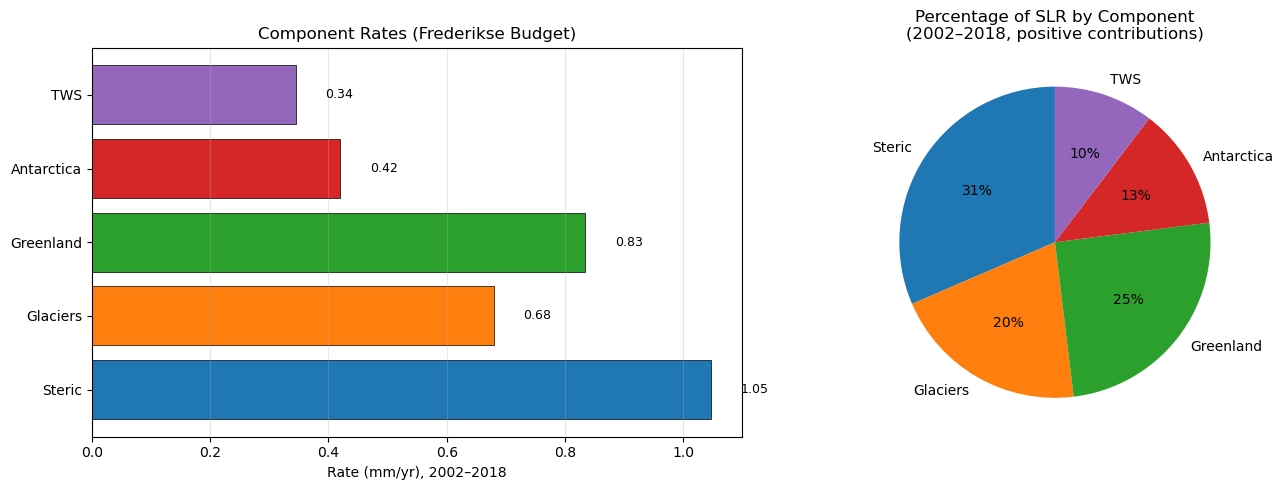

Saved: component_stage1_rates.png


In [20]:
# ── Rate pie chart ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Component rates bar chart
ax = axes[0]
comp_names = ['Steric', 'Glaciers', 'Greenland', 'Antarctica', 'TWS']
comp_rates = [components_rate[n] for n in comp_names]
comp_colors = ['C0', 'C1', 'C2', 'C3', 'C4']

bars = ax.barh(comp_names, comp_rates, color=comp_colors, edgecolor='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('Rate (mm/yr), 2002–2018')
ax.set_title('Component Rates (Frederikse Budget)')
for bar, rate in zip(bars, comp_rates):
    ax.text(rate + 0.05, bar.get_y() + bar.get_height()/2,
            f'{rate:.2f}', va='center', fontsize=9)
ax.grid(True, alpha=0.3, axis='x')

# Panel B: Percentage breakdown
ax = axes[1]
positive_rates = {n: max(r, 0) for n, r in zip(comp_names, comp_rates)}
total_pos = sum(positive_rates.values())
sizes = [positive_rates[n] / total_pos * 100 for n in comp_names]
wedges, texts, autotexts = ax.pie(
    sizes, labels=comp_names, autopct='%1.0f%%',
    colors=comp_colors, startangle=90)
ax.set_title('Percentage of SLR by Component\n(2002–2018, positive contributions)')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_stage1_rates.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Saved: component_stage1_rates.png')

## 9. Summary and Next Steps

### Stage 1 Results

**Thermosteric calibration:**
- The thermal expansion component is well-described by a nearly linear
  model: $a_{\text{th}} \approx 0$, confirming the expected physics.
- The steric sensitivity $b_{\text{th}}$ represents the dominant
  temperature response of thermal expansion.
- Thermosteric projections can be compared directly with IPCC ocean dynamics.

**Cryospheric residual:**
- The residual (GMSL − thermosteric) captures all mass contributions.
- This residual is validated against IMBIE + GlaMBIE direct observations.
- The residual contains essentially ALL of the quadratic acceleration
  (since thermosteric is approximately linear in T).

### Next stages
- **Stage 2a:** Fit glacier component using GlaMBIE data
- **Stage 2b:** Fit Greenland using IMBIE, with SMB/discharge separation
- **Stage 3:** TWS estimation
- **Stage 4:** Antarctic budget residual + A4 deep uncertainty

In [21]:
# ── Export Stage 1 results ──
import json

stage1_results = {
    'thermosteric_calibration': {
        'a_th_median_mm': float(np.median(a_th) * M_TO_MM),
        'a_th_90ci_mm': [float(np.percentile(a_th, 5) * M_TO_MM),
                         float(np.percentile(a_th, 95) * M_TO_MM)],
        'b_th_median_mm': float(np.median(b_th) * M_TO_MM),
        'b_th_90ci_mm': [float(np.percentile(b_th, 5) * M_TO_MM),
                         float(np.percentile(b_th, 95) * M_TO_MM)],
        'c_th_median_mm': float(np.median(c_th) * M_TO_MM),
        'c_th_90ci_mm': [float(np.percentile(c_th, 5) * M_TO_MM),
                         float(np.percentile(c_th, 95) * M_TO_MM)],
        'sigma_extra_median_mm': float(np.median(sigma_extra_th) * M_TO_MM),
        'R2': float(r2_thermo),
    },
    'component_rates_2002_2018_mm_yr': components_rate,
    'projections_at_2100': {},
    'config': {
        'data_source': 'Frederikse et al. (2020) steric component',
        'temperature': 'Berkeley Earth',
        'baseline_year': BASELINE_YEAR,
        'prior': {
            'a_th': f'Exponential(mean={PRIOR_SCALE_A_THERMO*M_TO_MM:.3f} mm/yr/°C²)',
            'b_th': f'HalfNormal(σ={PRIOR_SCALE_B_THERMO*M_TO_MM:.1f} mm/yr/°C)',
            'c_th': f'Normal({PRIOR_C_MEAN_THERMO*M_TO_MM:.1f}, {PRIOR_C_SIGMA_THERMO*M_TO_MM:.1f} mm/yr)',
        },
    },
}

for ssp in ssps_to_plot:
    if ssp in thermo_projections:
        proj = thermo_projections[ssp]
        stage1_results['projections_at_2100'][ssp] = {
            'thermosteric_median_mm': float(proj['median'][-1] * M_TO_MM),
            'thermosteric_90ci_mm': [
                float(proj['p5'][-1] * M_TO_MM),
                float(proj['p95'][-1] * M_TO_MM),
            ],
        }

out_path = '../data/processed/stage1_thermosteric_results.json'
with open(out_path, 'w') as f:
    json.dump(stage1_results, f, indent=2)

print(f'Results exported to {out_path}')
print(json.dumps(stage1_results, indent=2))

Results exported to ../data/processed/stage1_thermosteric_results.json
{
  "thermosteric_calibration": {
    "a_th_median_mm": 0.2434863377206272,
    "a_th_90ci_mm": [
      0.031973673700033664,
      0.5461592203804593
    ],
    "b_th_median_mm": 1.1008665166676022,
    "b_th_90ci_mm": [
      0.9381996368291307,
      1.3216641530291917
    ],
    "c_th_median_mm": 0.9894122359416524,
    "c_th_90ci_mm": [
      0.9571772534478727,
      1.0204976664158114
    ],
    "sigma_extra_median_mm": 1.12665156526585,
    "R2": 0.9797187122050197
  },
  "component_rates_2002_2018_mm_yr": {
    "Steric": 1.0465758021409919,
    "Glaciers": 0.6795629391483433,
    "Greenland": 0.83396210769815,
    "Antarctica": 0.4198276401296691,
    "TWS": 0.34423978604816036,
    "Total GMSL": 3.656878561586151
  },
  "projections_at_2100": {
    "SSP1-2.6": {
      "thermosteric_median_mm": 300.02963062667527,
      "thermosteric_90ci_mm": [
        231.04984834624844,
        391.48877865012787
      ]

---

## 10. Stage 2a: Glacier Component

Fit the rate–temperature model to the **glacier component** from the
Frederikse budget (1900–2018). Validate against:
- **GlaMBIE** global glacier consensus (2000–2023)
- **Horwath et al.** satellite-era budget (1993–2016)

Glaciers respond on timescales of ~10–50 yr, faster than ice sheets.
We expect moderate temperature sensitivity with possible nonlinearity
as warmer temperatures expose new ice area and accelerate calving.

In [ ]:
# ── Rebase glacier component to 2005 baseline ──
glacier_rebase = fred_glaciers - fred_glaciers[baseline_idx]
glacier_sigma = fred_glaciers_sigma.copy()

print(f'Glacier component: {fred_year[0]:.0f}–{fred_year[-1]:.0f}')
print(f'  At 1900: {fred_glaciers[0]*M_TO_MM:.1f} mm  (rebased: {glacier_rebase[0]*M_TO_MM:.1f} mm)')
print(f'  At 2005: {fred_glaciers[baseline_idx]*M_TO_MM:.1f} mm  (rebased: 0.0 mm)')
print(f'  At 2018: {fred_glaciers[-1]*M_TO_MM:.1f} mm  (rebased: {glacier_rebase[-1]*M_TO_MM:.1f} mm)')
print(f'  Mean sigma: {glacier_sigma.mean()*M_TO_MM:.1f} mm')

# ── Prior configuration for glaciers ──
# Glaciers may have moderate nonlinearity → less shrinkage on a_gl
PRIOR_SCALE_A_GLACIER = calibrate_exponential_prior(
    prob_exceed=0.10, threshold=0.003    # 3 mm/yr/°C² — broader than steric
)
PRIOR_SCALE_B_GLACIER = 0.005    # 5 mm/yr/°C
PRIOR_C_MEAN_GLACIER = 0.0003   # 0.3 mm/yr (small background trend)
PRIOR_C_SIGMA_GLACIER = 0.002   # 2 mm/yr
PRIOR_SIGMA_EXTRA_GLACIER = 0.002  # 2 mm
PRIOR_H0_SIGMA_GLACIER = 0.010  # 10 mm

print(f'\nGlacier prior:')
print(f'  a_gl ~ Exp(mean = {PRIOR_SCALE_A_GLACIER*M_TO_MM:.2f} mm/yr/°C²)')
print(f'  b_gl ~ HN(σ = {PRIOR_SCALE_B_GLACIER*M_TO_MM:.1f} mm/yr/°C)')
print(f'  c_gl ~ N({PRIOR_C_MEAN_GLACIER*M_TO_MM:.1f}, {PRIOR_C_SIGMA_GLACIER*M_TO_MM:.1f} mm/yr)')

# ── Fit Bayesian level-space model to glacier component ──
result_glacier = fit_bayesian_level(
    H_obs=glacier_rebase,
    sigma_obs=glacier_sigma,
    I2_obs=I2_obs,
    I1_obs=I1_obs,
    I0_obs=I0_obs,
    prior_scale_a=PRIOR_SCALE_A_GLACIER,
    prior_scale_b=PRIOR_SCALE_B_GLACIER,
    prior_c_mean=PRIOR_C_MEAN_GLACIER,
    prior_c_sigma=PRIOR_C_SIGMA_GLACIER,
    prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_GLACIER,
    prior_H0_sigma=PRIOR_H0_SIGMA_GLACIER,
    n_samples=4000,
    n_walkers=32,
    n_burnin=2000,
    thin=2,
    seed=44,
)

In [ ]:
# ── Report glacier calibration results ──
a_gl = result_glacier.posterior_samples[:, 0]
b_gl = result_glacier.posterior_samples[:, 1]
c_gl = result_glacier.posterior_samples[:, 2]
sigma_extra_gl = result_glacier.sigma_extra_posterior
H0_gl = result_glacier.H0_posterior

# R²
H_model_gl = np.median(a_gl) * I2_obs + np.median(b_gl) * I1_obs + \
             np.median(c_gl) * I0_obs + np.median(H0_gl)
ss_res_gl = np.sum((glacier_rebase - H_model_gl)**2)
ss_tot_gl = np.sum((glacier_rebase - np.mean(glacier_rebase))**2)
r2_glacier = 1 - ss_res_gl / ss_tot_gl

print('='*65)
print('GLACIER CALIBRATION RESULTS')
print('='*65)

for name, s, unit in [
    ('a_gl', a_gl * M_TO_MM, 'mm/yr/°C²'),
    ('b_gl', b_gl * M_TO_MM, 'mm/yr/°C'),
    ('c_gl', c_gl * M_TO_MM, 'mm/yr'),
    ('σ_extra', sigma_extra_gl * M_TO_MM, 'mm'),
    ('H₀', H0_gl * M_TO_MM, 'mm'),
]:
    p5, med, p95 = np.percentile(s, [5, 50, 95])
    print(f'  {name:12s} = {med:7.3f} [{p5:.3f}, {p95:.3f}] {unit}')

print(f'\n  R² = {r2_glacier:.4f}')
print(f'  P(a_gl > 0.5 mm/yr/°C²) = {np.mean(a_gl * M_TO_MM > 0.5):.1%}')
print('='*65)

In [ ]:
# ── Multi-dataset glacier validation ──
# Load Horwath glacier component (1993-2016, monthly, meters)
df_horwath = pd.read_hdf(H5_PATH, 'harmonized/df_horwath_h')
hw_years = df_horwath['decimal_year'].values
hw_glaciers = df_horwath['glaciers'].values
hw_glaciers_sigma = df_horwath['glaciers_sigma'].values

# Annualise Horwath (yearly mean)
hw_gl_annual = df_horwath[['decimal_year', 'glaciers', 'glaciers_sigma']].copy()
hw_gl_annual['year_int'] = hw_gl_annual['decimal_year'].astype(int)
hw_gl_yr = hw_gl_annual.groupby('year_int').agg({
    'glaciers': 'last',             # end-of-year cumulative
    'glaciers_sigma': 'last',
    'decimal_year': 'mean',
}).sort_index()

# Rebase Horwath and GlaMBIE to 2005 baseline
hw_gl_vals = hw_gl_yr['glaciers'].values
hw_gl_years = hw_gl_yr.index.values
idx_2005_hw = np.argmin(np.abs(hw_gl_years - 2005))
hw_gl_rebase = hw_gl_vals - hw_gl_vals[idx_2005_hw]

# GlaMBIE cumulative (already positive = SLR, from reader)
glac_years_gl = df_glac['decimal_year'].values
glac_cumul_m = np.cumsum(df_glac['mass_balance'].values)
idx_2005_glm = np.argmin(np.abs(glac_years_gl - 2005))
glac_cumul_rebase = glac_cumul_m - glac_cumul_m[idx_2005_glm]

# ── Validation figure ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Multi-dataset comparison
ax = axes[0]
# Frederikse
ax.plot(fred_year, glacier_rebase * M_TO_MM, 'k-', lw=2,
        label=f'Frederikse (1900–2018)')
ax.fill_between(fred_year,
                (glacier_rebase - 2*glacier_sigma) * M_TO_MM,
                (glacier_rebase + 2*glacier_sigma) * M_TO_MM,
                color='gray', alpha=0.15)
# Model fit
H_ens_gl = model_ensemble(result_glacier, I2_obs, I1_obs, I0_obs)
p5_gl, p50_gl, p95_gl = np.percentile(H_ens_gl * M_TO_MM, [5, 50, 95], axis=0)
ax.plot(fred_year, p50_gl, 'C1-', lw=2, label='Bayesian fit')
ax.fill_between(fred_year, p5_gl, p95_gl, color='C1', alpha=0.15, label='90% CI')

# Horwath
ax.plot(hw_gl_years, hw_gl_rebase * M_TO_MM, 'C2s', ms=3,
        label='Horwath (1993–2016)')

# GlaMBIE
ax.plot(glac_years_gl, glac_cumul_rebase * M_TO_MM, 'C3^', ms=4,
        label='GlaMBIE (2000–2023)')

ax.set_ylabel('Cumulative glacier SLR (mm, 2005 baseline)')
ax.set_xlabel('Year')
ax.set_title('Glacier Component — Multi-Dataset Validation')
ax.legend(loc='upper left', fontsize=7)
ax.grid(True, alpha=0.3)
ax.set_xlim(1900, 2025)

# Panel B: Satellite-era zoom
ax = axes[1]
ax.plot(fred_year, glacier_rebase * M_TO_MM, 'k-', lw=2,
        label='Frederikse')
ax.plot(fred_year, p50_gl, 'C1-', lw=2, label='Bayesian fit')
ax.fill_between(fred_year, p5_gl, p95_gl, color='C1', alpha=0.15)
ax.plot(hw_gl_years, hw_gl_rebase * M_TO_MM, 'C2s-', ms=4, lw=1,
        label='Horwath')
ax.plot(glac_years_gl, glac_cumul_rebase * M_TO_MM, 'C3^-', ms=4, lw=1,
        label='GlaMBIE')
ax.set_ylabel('Cumulative glacier SLR (mm)')
ax.set_xlabel('Year')
ax.set_title('Satellite Era Detail')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim(1990, 2025)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_stage2a_glaciers.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Saved: component_stage2a_glaciers.png')

In [ ]:
# ── Glacier projections under SSPs ──
glacier_projections = {}
mc_idx_gl = rng_proj.choice(len(a_gl), N_MC, replace=False)

for ssp in ssps_to_plot:
    if ssp not in thermo_projections:
        continue
    # Reuse the design vectors already built for thermosteric projections
    # Rebuild for glacier (same temperature, same obs_times)
    df_ssp = ipcc_temp_proj[ssp]
    ipcc_years_float = df_ssp['decimal_year'].values
    ipcc_temp_vals = df_ssp['temperature'].values

    hist_mask = temp_time_monthly <= 2020.0
    t_hist = temp_time_monthly[hist_mask]
    T_hist = temp_monthly[hist_mask]
    t_future = np.arange(2020.0 + 1/24, 2101.0, 1/12)
    T_future = np.interp(t_future, ipcc_years_float, ipcc_temp_vals)
    t_full = np.concatenate([t_hist, t_future])
    T_full = np.concatenate([T_hist, T_future])

    dv_proj = build_level_design_vectors(
        temperature_monthly=T_full,
        time_monthly=t_full,
        obs_times=np.concatenate([fred_year, proj_years.astype(float)]),
    )
    n_obs = len(fred_year)
    I2p = dv_proj['I2_obs'][n_obs:]
    I1p = dv_proj['I1_obs'][n_obs:]
    I0p = dv_proj['I0_obs'][n_obs:]

    ens = np.zeros((N_MC, len(proj_years)))
    for i, j in enumerate(mc_idx_gl):
        ens[i] = a_gl[j] * I2p + b_gl[j] * I1p + c_gl[j] * I0p + H0_gl[j]

    glacier_projections[ssp] = {
        'years': proj_years,
        'samples': ens,
        'median': np.median(ens, axis=0),
        'p5': np.percentile(ens, 5, axis=0),
        'p95': np.percentile(ens, 95, axis=0),
    }
    med_2100 = glacier_projections[ssp]['median'][-1] * M_TO_MM
    lo_2100 = glacier_projections[ssp]['p5'][-1] * M_TO_MM
    hi_2100 = glacier_projections[ssp]['p95'][-1] * M_TO_MM
    print(f'  {ssp}: Glaciers at 2100 = {med_2100:.0f} [{lo_2100:.0f}, {hi_2100:.0f}] mm')

# Compare with IPCC glacier projections
print('\nIPCC AR6 glacier projections at 2100 (mm):')
for ssp in ssps_to_plot:
    ssp_code = ssp.lower().replace('-', '').replace('.', '')
    try:
        df_ipcc_gl = read_ipcc_ar6_component(COMP_DIR, 'glaciers', scenario=ssp_code)
        print(f'  {ssp}: IPCC median = {df_ipcc_gl["median"].iloc[-1]*M_TO_MM:.0f} mm '
              f'[{df_ipcc_gl["p5"].iloc[-1]*M_TO_MM:.0f}, '
              f'{df_ipcc_gl["p95"].iloc[-1]*M_TO_MM:.0f}]')
    except FileNotFoundError:
        pass

---

## 11. Stage 2b: Physics-Informed Greenland Ice Sheet Model

Replace the phenomenological polynomial with a **two-component** model
separating surface mass balance (SMB) and ice-dynamic discharge:

$$H_{\text{GrIS}}(t) = \underbrace{a_{\text{eff}} I_2 + b_{\text{eff}} I_1}_{\text{SMB (instantaneous)}} + \underbrace{\gamma \int_0^t D_{\text{eff}}(\tau)\,d\tau}_{\text{Discharge (lagged)}} + c\,I_0 + H_0$$

**SMB** (55–92% of total) responds instantaneously to surface temperature
with polar amplification absorbed into $a_{\text{eff}}$ and $b_{\text{eff}}$.

**Discharge** (8–45%, Aschwanden et al. 2019) responds with a
multi-decadal relaxation lag $\tau_{\text{dyn}} \sim 10\text{–}50$ yr
via a single-layer ODE:

$$\frac{dD_{\text{eff}}}{dt} = \frac{T(t) - D_{\text{eff}}}{\tau_{\text{dyn}}}$$

Validation targets (Aschwanden & Brinkerhoff 2022, calibrated):
- SSP1-2.6 ≈ RCP 2.6: **8 [4, 14] cm**
- SSP5-8.5 ≈ RCP 8.5: **19 [9, 29] cm**
- Discharge fraction: 8–45% of total

In [ ]:
# ── Rebase Greenland component to 2005 baseline ──
from bayesian_dols import fit_bayesian_greenland, solve_twolayer_ode

greenland_rebase = fred_greenland - fred_greenland[baseline_idx]
greenland_sigma = fred_greenland_sigma.copy()

print(f'Greenland component: {fred_year[0]:.0f}–{fred_year[-1]:.0f}')
print(f'  At 1900: {fred_greenland[0]*M_TO_MM:.1f} mm  (rebased: {greenland_rebase[0]*M_TO_MM:.1f} mm)')
print(f'  At 2005: {fred_greenland[baseline_idx]*M_TO_MM:.1f} mm  (rebased: 0.0 mm)')
print(f'  At 2018: {fred_greenland[-1]*M_TO_MM:.1f} mm  (rebased: {greenland_rebase[-1]*M_TO_MM:.1f} mm)')
print(f'  Mean sigma: {greenland_sigma.mean()*M_TO_MM:.1f} mm')

# ── Prior configuration for physics-informed Greenland model ──
# a_eff = β_smb·f²_arctic: SMB nonlinearity × amplification²
# PC prior: P(a_eff > 3 mm/yr/°C²) = 20%
PRIOR_SCALE_A_GR = calibrate_exponential_prior(
    prob_exceed=0.20, threshold=0.003
)
# b_eff = α_smb·f_arctic: expected 0.6–0.8 mm/yr/°C from
# SMB literature (Hanna 2021, ~90–115 Gt/yr/°C × f_arctic ≈ 2.5)
PRIOR_SCALE_B_GR = 0.003     # HalfNormal σ = 3 mm/yr/°C

# γ: discharge sensitivity (m/yr per °C-equivalent)
# Discharge = 8–45% of total; at D_eff ~ 0.5°C → 0.07–0.37 mm/yr
PRIOR_SCALE_GAMMA_GR = 0.001  # HalfNormal σ = 1 mm/yr/°C

# τ_dyn: ice-dynamic response time for marine-terminating outlets
# Median 20 yr, 94% CI [7, 55]; Straneo & Cenedese 2015, ISMIP6
PRIOR_LOG_TAU_MEAN = np.log(20.0)
PRIOR_LOG_TAU_SIGMA = 0.6

# c: small secular drift (background + GIA correction)
PRIOR_C_MEAN_GR = 0.0002    # 0.2 mm/yr
PRIOR_C_SIGMA_GR = 0.0005   # 0.5 mm/yr

# σ_extra: model inadequacy scale
PRIOR_SIGMA_EXTRA_GR = 0.002  # 2 mm

# H₀: baseline offset
PRIOR_H0_SIGMA_GR = 0.005   # 5 mm

print(f'\nPhysics-informed Greenland prior:')
print(f'  a_eff ~ Exp(mean = {PRIOR_SCALE_A_GR*M_TO_MM:.2f} mm/yr/°C²)')
print(f'  b_eff ~ HN(σ = {PRIOR_SCALE_B_GR*M_TO_MM:.1f} mm/yr/°C)')
print(f'  γ     ~ HN(σ = {PRIOR_SCALE_GAMMA_GR*M_TO_MM:.1f} mm/yr/°C)')
print(f'  τ_dyn ~ LogN(log({np.exp(PRIOR_LOG_TAU_MEAN):.0f}), {PRIOR_LOG_TAU_SIGMA})')

# ── Fit physics-informed Greenland model ──
result_greenland_phys = fit_bayesian_greenland(
    H_obs=greenland_rebase,
    sigma_obs=greenland_sigma,
    I2_obs=I2_obs,
    I1_obs=I1_obs,
    I0_obs=I0_obs,
    T_monthly=temp_monthly,
    time_monthly=temp_time_monthly,
    obs_times=fred_year,
    prior_scale_a=PRIOR_SCALE_A_GR,
    prior_scale_b=PRIOR_SCALE_B_GR,
    prior_scale_gamma=PRIOR_SCALE_GAMMA_GR,
    prior_log_tau_mean=PRIOR_LOG_TAU_MEAN,
    prior_log_tau_sigma=PRIOR_LOG_TAU_SIGMA,
    prior_c_mean=PRIOR_C_MEAN_GR,
    prior_c_sigma=PRIOR_C_SIGMA_GR,
    prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_GR,
    prior_H0_sigma=PRIOR_H0_SIGMA_GR,
    n_samples=5000,
    n_walkers=64,
    n_burnin=3000,
    seed=2025,
    progress=True,
)

# ── Backward compatibility for combined assessment (cells 49-53) ──
# a_gr, b_gr, c_gr: polynomial-equivalent coefficients
# Note: b_gr = b_eff (SMB only); discharge contribution (γ·∫D_eff)
# is captured in the full physics-informed model but NOT in these
# polynomial coefficients.
a_gr = result_greenland_phys.posterior_samples[:, 0]   # a_eff
b_gr = result_greenland_phys.posterior_samples[:, 1]   # b_eff
gamma_gr = result_greenland_phys.posterior_samples[:, 2]  # γ (discharge)
c_gr = result_greenland_phys.posterior_samples[:, 3]   # c
H0_gr = result_greenland_phys.H0_posterior
r2_greenland = result_greenland_phys.r2
result_greenland = result_greenland_phys  # alias for validation cell

In [ ]:
# ── Physics-informed Greenland diagnostics ──
import arviz as az

print('='*65)
print('GREENLAND PHYSICS-INFORMED CALIBRATION RESULTS')
print('='*65)

a_eff_samples = result_greenland_phys.posterior_samples[:, 0]
b_eff_samples = result_greenland_phys.posterior_samples[:, 1]
gamma_samples = result_greenland_phys.posterior_samples[:, 2]
c_samples_gr  = result_greenland_phys.posterior_samples[:, 3]
tau_dyn_samples = result_greenland_phys.tau_dyn_posterior
sigma_extra_gr = result_greenland_phys.sigma_extra_posterior

for name, s, unit in [
    ('a_eff (SMB)', a_eff_samples * M_TO_MM, 'mm/yr/°C²'),
    ('b_eff (SMB)', b_eff_samples * M_TO_MM, 'mm/yr/°C'),
    ('γ (discharge)', gamma_samples * M_TO_MM, 'mm/yr/°C'),
    ('c (drift)', c_samples_gr * M_TO_MM, 'mm/yr'),
    ('τ_dyn', tau_dyn_samples, 'yr'),
    ('σ_extra', sigma_extra_gr * M_TO_MM, 'mm'),
    ('H₀', H0_gr * M_TO_MM, 'mm'),
]:
    p3, p50, p97 = np.percentile(s, [3, 50, 97])
    print(f'  {name:14s} = {p50:8.3f} [{p3:.3f}, {p97:.3f}] {unit}')

print(f'\n  R² = {r2_greenland:.4f}')

# Discharge fraction at 2018
H_smb_change = result_greenland_phys.H_smb_mean[-1] - result_greenland_phys.H_smb_mean[0]
H_dyn_change = result_greenland_phys.H_dyn_mean[-1] - result_greenland_phys.H_dyn_mean[0]
H_total_change = result_greenland_phys.H_model_mean[-1] - result_greenland_phys.H_model_mean[0]
if abs(H_total_change) > 1e-8:
    smb_frac = H_smb_change / H_total_change
    dyn_frac = H_dyn_change / H_total_change
    print(f'\n  Component fractions (1900–2018 change):')
    print(f'    SMB:       {H_smb_change*M_TO_MM:6.1f} mm  ({smb_frac:5.1%})')
    print(f'    Discharge: {H_dyn_change*M_TO_MM:6.1f} mm  ({dyn_frac:5.1%})')
    print(f'    Total:     {H_total_change*M_TO_MM:6.1f} mm')
    print(f'  Target: discharge 8–45% (Aschwanden 2019)')
print('='*65)

# ── Posterior histograms ──
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# a_eff
ax = axes[0, 0]
ax.hist(a_eff_samples * M_TO_MM, bins=50, density=True, alpha=0.7, color='C0')
ax.axvline(np.median(a_eff_samples) * M_TO_MM, color='k', ls='--')
ax.set_xlabel(r'$a_{\mathrm{eff}}$ (mm/yr/°C²)')
ax.set_title('SMB nonlinearity')

# b_eff
ax = axes[0, 1]
ax.hist(b_eff_samples * M_TO_MM, bins=50, density=True, alpha=0.7, color='C1')
ax.axvline(np.median(b_eff_samples) * M_TO_MM, color='k', ls='--')
ax.set_xlabel(r'$b_{\mathrm{eff}}$ (mm/yr/°C)')
ax.set_title('SMB linear sensitivity')

# γ
ax = axes[0, 2]
ax.hist(gamma_samples * M_TO_MM, bins=50, density=True, alpha=0.7, color='C2')
ax.axvline(np.median(gamma_samples) * M_TO_MM, color='k', ls='--')
ax.set_xlabel(r'$\gamma$ (mm/yr/°C)')
ax.set_title('Discharge sensitivity')

# τ_dyn
ax = axes[1, 0]
ax.hist(tau_dyn_samples, bins=50, density=True, alpha=0.7, color='C3')
ax.axvline(np.median(tau_dyn_samples), color='k', ls='--')
ax.set_xlabel(r'$\tau_{\mathrm{dyn}}$ (yr)')
ax.set_title('Ice-dynamic lag')

# σ_extra
ax = axes[1, 1]
ax.hist(sigma_extra_gr * M_TO_MM, bins=50, density=True, alpha=0.7, color='C4')
ax.axvline(np.median(sigma_extra_gr) * M_TO_MM, color='k', ls='--')
ax.set_xlabel(r'$\sigma_{\mathrm{extra}}$ (mm)')
ax.set_title('Model inadequacy')

# Discharge fraction posterior
ax = axes[1, 2]
# Estimate discharge fraction from posterior samples for satellite era (2002-2018)
# Approximate using b_eff and γ contributions at representative temperature
dyn_frac_post = gamma_samples / (b_eff_samples + gamma_samples + 1e-12)
ax.hist(dyn_frac_post * 100, bins=50, density=True, alpha=0.7, color='C5')
ax.axvspan(8, 45, alpha=0.15, color='gray', label='Aschwanden 8–45%')
ax.set_xlabel('Discharge fraction (%)')
ax.set_title('γ/(b_eff + γ) ratio')
ax.legend(fontsize=8)

fig.suptitle('Greenland Physics-Informed Model: Posterior Distributions', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_greenland_phys_posteriors.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Saved: component_greenland_phys_posteriors.png')

In [ ]:
# ── Physics-informed Greenland: decomposition + validation figure ──

# Horwath Greenland (1993-2016, monthly, meters)
hw_gr_annual = df_horwath[['decimal_year', 'greenland', 'greenland_sigma']].copy()
hw_gr_annual['year_int'] = hw_gr_annual['decimal_year'].astype(int)
hw_gr_yr = hw_gr_annual.groupby('year_int').agg({
    'greenland': 'last',
    'greenland_sigma': 'last',
    'decimal_year': 'mean',
}).sort_index()
hw_gr_years = hw_gr_yr.index.values
hw_gr_vals = hw_gr_yr['greenland'].values
idx_2005_hw_gr = np.argmin(np.abs(hw_gr_years - 2005))
hw_gr_rebase = hw_gr_vals - hw_gr_vals[idx_2005_hw_gr]

# IMBIE Greenland → SLR contribution = -cumulative_mass_balance
gris_yr_ann = df_gris['cumulative_mass_balance'].resample('YE').last()
gris_years = gris_yr_ann.index.year
gris_slr = -gris_yr_ann.values  # negate: mass loss → positive SLR
idx_2005_gris = np.argmin(np.abs(gris_years - 2005))
gris_slr_rebase = gris_slr - gris_slr[idx_2005_gris]

# ── 3-panel figure ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel A: Total model fit + multi-dataset validation
ax = axes[0]
ax.errorbar(fred_year, greenland_rebase * M_TO_MM,
            yerr=2*greenland_sigma * M_TO_MM,
            fmt='o', ms=2, color='k', alpha=0.4, label='Frederikse (1900–2018)')

# Physics-informed model prediction
ax.plot(fred_year, result_greenland_phys.H_model_mean * M_TO_MM,
        'C2-', lw=2, label='Physics-informed fit')

# Validation datasets
ax.plot(hw_gr_years, hw_gr_rebase * M_TO_MM, 'C1s', ms=3,
        label='Horwath (1993–2016)')
ax.plot(gris_years, gris_slr_rebase * M_TO_MM, 'C3^', ms=3,
        label='IMBIE GrIS (1992–2020)')

ax.set_ylabel('Cumulative Greenland SLR (mm)')
ax.set_xlabel('Year')
ax.set_title(f'(a) Model Fit & Validation  (R² = {r2_greenland:.4f})')
ax.legend(loc='upper left', fontsize=7)
ax.grid(True, alpha=0.3)

# Panel B: Component decomposition (SMB vs discharge vs secular)
ax = axes[1]
H_smb = result_greenland_phys.H_smb_mean
H_dyn = result_greenland_phys.H_dyn_mean
c_med = np.median(c_gr)
H_sec = c_med * I0_obs  # secular drift contribution

ax.plot(fred_year, (H_smb - H_smb[baseline_idx]) * M_TO_MM,
        'C0-', lw=2, label='SMB (a·I₂ + b·I₁)')
ax.plot(fred_year, (H_dyn - H_dyn[baseline_idx]) * M_TO_MM,
        'C3-', lw=2, label=r'Discharge ($\gamma \int D_{\rm eff}$)')
ax.plot(fred_year, (H_sec - H_sec[baseline_idx]) * M_TO_MM,
        'C4--', lw=1.5, label='Secular drift (c·I₀)')
ax.plot(fred_year, result_greenland_phys.H_model_mean * M_TO_MM,
        'k-', lw=2, alpha=0.7, label='Total')
ax.plot(fred_year, greenland_rebase * M_TO_MM,
        'o', ms=2, color='gray', alpha=0.3, label='Observed')

ax.set_ylabel('Contribution (mm, 2005 baseline)')
ax.set_xlabel('Year')
ax.set_title('(b) SMB vs Discharge Decomposition')
ax.legend(loc='upper left', fontsize=7)
ax.grid(True, alpha=0.3)

# Panel C: D_eff(t) vs T(t) — showing the discharge lag
ax = axes[2]
# Plot monthly temperature and D_eff
D_eff = result_greenland_phys.D_eff_mean
tau_med = np.median(tau_dyn_samples)

# Annual average for cleaner plot
year_fl = np.floor(temp_time_monthly).astype(int)
unique_yr = np.unique(year_fl)
T_ann_avg = np.array([np.mean(temp_monthly[year_fl == y]) for y in unique_yr])
D_ann_avg = np.array([np.mean(D_eff[year_fl == y]) for y in unique_yr])

ax.plot(unique_yr, T_ann_avg, 'C0-', lw=1.5, alpha=0.7, label='GMST T(t)')
ax.plot(unique_yr, D_ann_avg, 'C3-', lw=2,
        label=f'$D_{{\\rm eff}}(t)$ (τ = {tau_med:.0f} yr)')
ax.fill_between(unique_yr, T_ann_avg, D_ann_avg,
                alpha=0.1, color='C3', label='Committed warming')
ax.set_ylabel('Temperature anomaly (°C)')
ax.set_xlabel('Year')
ax.set_title(f'(c) Discharge Temperature Lag (τ_dyn = {tau_med:.0f} yr)')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_greenland_phys_decomposition.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Saved: component_greenland_phys_decomposition.png')

In [ ]:
# ── Physics-informed Greenland projections under SSPs ──
greenland_projections = {}
mc_idx_gr = rng_proj.choice(len(a_gr), N_MC, replace=False)

# Projection arrays from posterior
a_eff_mc = a_eff_samples
b_eff_mc = b_eff_samples
gamma_mc = gamma_samples
c_mc_gr  = c_samples_gr
tau_mc   = tau_dyn_samples

print('Greenland physics-informed projections at 2100 (mm, 2005 baseline):')
print(f'  {"SSP":10s} {"Total":>18s} {"SMB":>18s} {"Discharge":>18s} {"Dyn%":>6s}')
print('-'*70)

for ssp in ssps_to_plot:
    if ssp not in ipcc_temp_proj:
        continue
    df_ssp = ipcc_temp_proj[ssp]
    ipcc_years_float = df_ssp['decimal_year'].values
    ipcc_temp_vals = df_ssp['temperature'].values

    # Build monthly temperature: historical + projected
    hist_mask = temp_time_monthly <= 2020.0
    t_hist = temp_time_monthly[hist_mask]
    T_hist = temp_monthly[hist_mask]
    t_future = np.arange(2020.0 + 1/24, 2101.0, 1/12)
    T_future = np.interp(t_future, ipcc_years_float, ipcc_temp_vals)
    t_full = np.concatenate([t_hist, t_future])
    T_full = np.concatenate([T_hist, T_future])

    # Design vectors on full grid
    dv_proj = build_level_design_vectors(
        temperature_monthly=T_full,
        time_monthly=t_full,
        obs_times=np.concatenate([fred_year, proj_years.astype(float)]),
    )
    n_obs = len(fred_year)
    I2p = dv_proj['I2_obs'][n_obs:]
    I1p = dv_proj['I1_obs'][n_obs:]
    I0p = dv_proj['I0_obs'][n_obs:]
    proj_full_idx = dv_proj['obs_idx'][n_obs:]  # indices into full monthly grid

    # Pre-compute dt on full monthly grid (for cumulative ∫D_eff)
    dt_full = np.diff(t_full)

    # MC ensemble with physics-informed model
    ens_total = np.zeros((N_MC, len(proj_years)))
    ens_smb   = np.zeros((N_MC, len(proj_years)))
    ens_dyn   = np.zeros((N_MC, len(proj_years)))

    for i, j in enumerate(mc_idx_gr):
        # Discharge ODE on full timeline
        D_eff_k, _ = solve_twolayer_ode(T_full, t_full, tau_mc[j], np.inf)

        # Cumulative ∫D_eff (vectorised trapezoidal)
        D_mid = 0.5 * (D_eff_k[:-1] + D_eff_k[1:])
        cum_D = np.concatenate([[0], np.cumsum(D_mid * dt_full)])
        cum_D_p = cum_D[proj_full_idx]

        # Components
        H_smb_k = a_eff_mc[j] * I2p + b_eff_mc[j] * I1p
        H_dyn_k = gamma_mc[j] * cum_D_p
        H_tot_k = H_smb_k + H_dyn_k + c_mc_gr[j] * I0p + H0_gr[j]

        ens_total[i] = H_tot_k
        ens_smb[i] = H_smb_k
        ens_dyn[i] = H_dyn_k

    # Store (backward-compatible dict format)
    greenland_projections[ssp] = {
        'years': proj_years,
        'samples': ens_total,
        'median': np.median(ens_total, axis=0),
        'p5': np.percentile(ens_total, 5, axis=0),
        'p95': np.percentile(ens_total, 95, axis=0),
        'p17': np.percentile(ens_total, 17, axis=0),
        'p83': np.percentile(ens_total, 83, axis=0),
        'samples_smb': ens_smb,
        'samples_dyn': ens_dyn,
        'median_smb': np.median(ens_smb, axis=0),
        'median_dyn': np.median(ens_dyn, axis=0),
    }

    # Report at 2100
    tot = greenland_projections[ssp]['median'][-1] * M_TO_MM
    tot_lo = greenland_projections[ssp]['p5'][-1] * M_TO_MM
    tot_hi = greenland_projections[ssp]['p95'][-1] * M_TO_MM
    smb_2100 = np.median(ens_smb, axis=0)[-1] * M_TO_MM
    dyn_2100 = np.median(ens_dyn, axis=0)[-1] * M_TO_MM
    dyn_pct = dyn_2100 / tot * 100 if abs(tot) > 0.1 else 0
    print(f'  {ssp:10s} {tot:5.0f} [{tot_lo:.0f}, {tot_hi:.0f}]'
          f'   {smb_2100:5.0f}              {dyn_2100:5.0f}            {dyn_pct:4.0f}%')

# ── Compare with IPCC and Aschwanden ──
print('\n' + '='*70)
print('COMPARISON WITH IPCC GIS AND ASCHWANDEN ET AL.')
print('='*70)
print(f'  {"SSP":10s} {"This model":>15s} {"IPCC GIS":>15s} {"Aschwanden":>15s}')
print('-'*60)

# Aschwanden calibrated (2022) at 2100 (cm → mm)
aschw = {
    'SSP1-2.6': (80, 40, 140),   # median, lo, hi  (mm)
    'SSP2-4.5': (110, 50, 180),
    'SSP5-8.5': (190, 90, 290),
}

for ssp in ssps_to_plot:
    if ssp not in greenland_projections:
        continue

    ours = greenland_projections[ssp]['median'][-1] * M_TO_MM
    ours_lo = greenland_projections[ssp]['p5'][-1] * M_TO_MM
    ours_hi = greenland_projections[ssp]['p95'][-1] * M_TO_MM
    ours_str = f'{ours:.0f} [{ours_lo:.0f},{ours_hi:.0f}]'

    # IPCC
    ssp_code = ssp.lower().replace('-', '').replace('.', '')
    try:
        df_ipcc_gis = read_ipcc_ar6_component(
            COMP_DIR, 'icesheets', sub_component='GIS', scenario=ssp_code)
        ipcc_2100 = df_ipcc_gis.loc[2100, 'median'] * M_TO_MM
        ipcc_lo = df_ipcc_gis.loc[2100, 'p05'] * M_TO_MM
        ipcc_hi = df_ipcc_gis.loc[2100, 'p95'] * M_TO_MM
        ipcc_str = f'{ipcc_2100:.0f} [{ipcc_lo:.0f},{ipcc_hi:.0f}]'
    except Exception:
        ipcc_str = 'N/A'

    # Aschwanden
    if ssp in aschw:
        a_med, a_lo, a_hi = aschw[ssp]
        aschw_str = f'{a_med:.0f} [{a_lo:.0f},{a_hi:.0f}]'
    else:
        aschw_str = 'N/A'

    print(f'  {ssp:10s} {ours_str:>15s} {ipcc_str:>15s} {aschw_str:>15s}')

print('='*60)
print('Aschwanden: calibrated Aschwanden & Brinkerhoff (2022), cm→mm')

---

## 12. Combined Assessment: Stages 1 + 2a + 2b

Combine the three fitted components (thermosteric + glaciers + Greenland)
and assess:
1. How much of total GMSL is explained by these three components
2. The implied Antarctica + TWS residual
3. How the quadratic acceleration ($a$) partitions across components
4. Projection comparison with IPCC at 2100

In [ ]:
# ── Coefficient comparison: all four models ──
print('COMPONENT COEFFICIENT COMPARISON')
print('All values: median [5%, 95%] in mm/yr units')
print('='*80)
print(f'{"Component":15s} {"a (dα/dT)":>25s}  {"b (α₀)":>25s}  {"c (trend)":>25s}')
print('-'*80)

comp_data = [
    ('Total GMSL', a_total, b_total, c_total),
    ('Thermosteric', a_th, b_th, c_th),
    ('Glaciers', a_gl, b_gl, c_gl),
    ('Greenland', a_gr, b_gr, c_gr),
]

for label, a_arr, b_arr, c_arr in comp_data:
    def fmt(arr):
        s = arr * M_TO_MM
        return f'{np.median(s):5.2f} [{np.percentile(s,5):5.2f},{np.percentile(s,95):5.2f}]'
    print(f'  {label:13s}  {fmt(a_arr):>25s}  {fmt(b_arr):>25s}  {fmt(c_arr):>25s}')

# Sum of 3 components
n_min = min(len(a_th), len(a_gl), len(a_gr))
a_sum = (a_th[:n_min] + a_gl[:n_min] + a_gr[:n_min]) * M_TO_MM
b_sum = (b_th[:n_min] + b_gl[:n_min] + b_gr[:n_min]) * M_TO_MM
c_sum = (c_th[:n_min] + c_gl[:n_min] + c_gr[:n_min]) * M_TO_MM

def fmt_arr(arr):
    return f'{np.median(arr):5.2f} [{np.percentile(arr,5):5.2f},{np.percentile(arr,95):5.2f}]'

print(f'  {"Σ(3 comps)":13s}  {fmt_arr(a_sum):>25s}  {fmt_arr(b_sum):>25s}  {fmt_arr(c_sum):>25s}')

# Residual = total - 3 components
a_resid = (a_total[:n_min] * M_TO_MM) - a_sum
b_resid = (b_total[:n_min] * M_TO_MM) - b_sum
c_resid = (c_total[:n_min] * M_TO_MM) - c_sum
print(f'  {"AIS+TWS resid":13s}  {fmt_arr(a_resid):>25s}  {fmt_arr(b_resid):>25s}  {fmt_arr(c_resid):>25s}')
print('='*80)

# Percentage of quadratic acceleration from each component
a_tot_med = np.median(a_total) * M_TO_MM
print(f'\nPartition of quadratic acceleration a (dα/dT):')
print(f'  Total GMSL a = {a_tot_med:.2f} mm/yr/°C²')
for label, a_arr in [('Thermosteric', a_th), ('Glaciers', a_gl),
                      ('Greenland', a_gr)]:
    a_med = np.median(a_arr) * M_TO_MM
    pct = a_med / a_tot_med * 100
    print(f'  {label:13s}: {a_med:.2f} mm/yr/°C²  ({pct:5.1f}%)')
a_resid_med = np.median(a_resid)
print(f'  {"AIS+TWS":13s}: {a_resid_med:.2f} mm/yr/°C²  ({a_resid_med/a_tot_med*100:5.1f}%)')

In [ ]:
# ── Antarctica + TWS residual ──
# Observed residual = GMSL - steric_fit - glacier_fit - greenland_fit
H_3comp_median = (np.median(a_th) * I2_obs + np.median(b_th) * I1_obs +
                  np.median(c_th) * I0_obs + np.median(H0_th) +
                  np.median(a_gl) * I2_obs + np.median(b_gl) * I1_obs +
                  np.median(c_gl) * I0_obs + np.median(H0_gl) +
                  np.median(a_gr) * I2_obs + np.median(b_gr) * I1_obs +
                  np.median(c_gr) * I0_obs + np.median(H0_gr))

resid_ais_tws = gmsl_rebase - H_3comp_median

# Compare with Frederikse AIS + TWS
fred_ais_tws = (fred_antarctica + fred_tws)
fred_ais_tws_rebase = fred_ais_tws - fred_ais_tws[baseline_idx]

print('Antarctica + TWS residual at 2018:')
print(f'  GMSL − (thermo+glac+GrIS) fit:  {resid_ais_tws[-1]*M_TO_MM:6.1f} mm')
print(f'  Frederikse AIS+TWS direct:       {fred_ais_tws_rebase[-1]*M_TO_MM:6.1f} mm')
print(f'  Difference:                       '
      f'{(resid_ais_tws[-1]-fred_ais_tws_rebase[-1])*M_TO_MM:6.1f} mm')

# R² of 3-component sum against total GMSL
ss_res_3 = np.sum((gmsl_rebase - H_3comp_median)**2)
ss_tot_3 = np.sum((gmsl_rebase - np.mean(gmsl_rebase))**2)
r2_3comp = 1 - ss_res_3 / ss_tot_3
print(f'\nThree-component R² against total GMSL: {r2_3comp:.4f}')
print(f'  (vs single-model total GMSL R²:       {result_total.r2:.4f})')

# ── Plot: 3-component fit vs observed GMSL ──
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# Panel A: Stacked components vs GMSL
ax = axes[0]
ax.plot(fred_year, gmsl_rebase * M_TO_MM, 'k-', lw=2,
        label='Observed GMSL (Frederikse)')

# Stack the 3 component fits
H_th = np.median(a_th) * I2_obs + np.median(b_th) * I1_obs + \
       np.median(c_th) * I0_obs + np.median(H0_th)
H_gl = np.median(a_gl) * I2_obs + np.median(b_gl) * I1_obs + \
       np.median(c_gl) * I0_obs + np.median(H0_gl)
H_gr = np.median(a_gr) * I2_obs + np.median(b_gr) * I1_obs + \
       np.median(c_gr) * I0_obs + np.median(H0_gr)

ax.fill_between(fred_year, 0, H_th * M_TO_MM, color='C0', alpha=0.4,
                label='Thermosteric fit')
ax.fill_between(fred_year, H_th * M_TO_MM, (H_th + H_gl) * M_TO_MM,
                color='C1', alpha=0.4, label='Glacier fit')
ax.fill_between(fred_year, (H_th + H_gl) * M_TO_MM,
                (H_th + H_gl + H_gr) * M_TO_MM,
                color='C2', alpha=0.4, label='Greenland fit')
ax.plot(fred_year, H_3comp_median * M_TO_MM, 'r--', lw=1.5,
        label='Sum (thermo + glac + GrIS)')

ax.set_ylabel('Cumulative SLR (mm, 2005 baseline)')
ax.set_title('Observed GMSL vs Three-Component Fit')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# Panel B: Residual = Antarctica + TWS
ax = axes[1]
ax.plot(fred_year, resid_ais_tws * M_TO_MM, 'k-', lw=2,
        label='GMSL − 3-comp fit (= AIS + TWS)')
ax.plot(fred_year, fred_ais_tws_rebase * M_TO_MM, 'C3--', lw=2,
        label='Frederikse AIS + TWS (direct)')

# IMBIE AIS
ais_yr_ann = df_ais['cumulative_mass_balance'].resample('YE').last()
ais_years = ais_yr_ann.index.year
ais_slr = -ais_yr_ann.values
idx_2005_ais = np.argmin(np.abs(ais_years - 2005))
ais_slr_rebase = ais_slr - ais_slr[idx_2005_ais]
ax.plot(ais_years, ais_slr_rebase * M_TO_MM, 'C3^-', ms=3, lw=1,
        label='IMBIE AIS (1992–2020)')

ax.set_ylabel('Cumulative SLR (mm)')
ax.set_xlabel('Year')
ax.set_title('Antarctica + TWS Residual')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
ax.axhline(0, color='gray', ls=':', lw=0.5)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_stage2_combined.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Saved: component_stage2_combined.png')

In [ ]:
# ── Projection comparison at 2100: component sum vs IPCC total ──
print('PROJECTION SUMMARY AT 2100 (mm, 2005 baseline)')
print('='*75)
print(f'{"SSP":10s} {"Thermo":>12s} {"Glaciers":>12s} {"Greenland":>12s} '
      f'{"3-comp sum":>12s} {"IPCC GMSL":>12s}')
print('-'*75)

for ssp in ssps_to_plot:
    th_med = thermo_projections[ssp]['median'][-1] * M_TO_MM
    gl_med = glacier_projections[ssp]['median'][-1] * M_TO_MM
    gr_med = greenland_projections[ssp]['median'][-1] * M_TO_MM
    total_3 = th_med + gl_med + gr_med

    # IPCC total GMSL
    ssp_code = ssp.lower().replace('-', '').replace('.', '')
    try:
        df_ipcc_gmsl = pd.read_hdf(H5_PATH, f'projections/gmsl/{ssp_code}')
        ipcc_2100 = df_ipcc_gmsl['gmsl'].iloc[-1] * M_TO_MM
        ipcc_str = f'{ipcc_2100:.0f}'
    except Exception:
        ipcc_str = 'N/A'

    print(f'  {ssp:8s} {th_med:10.0f}   {gl_med:10.0f}   {gr_med:10.0f}   '
          f'{total_3:10.0f}   {ipcc_str:>10s}')

print('='*75)
print('\nNote: 3-component sum excludes Antarctica + TWS.')
print('IPCC GMSL is the full AR6 medium-confidence projection.')

In [ ]:
# ── Export Stage 1 + 2 results ──
import json

def median_ci(arr, to_mm=True):
    s = arr * M_TO_MM if to_mm else arr
    return {
        'median': float(np.median(s)),
        'ci_90': [float(np.percentile(s, 5)), float(np.percentile(s, 95))],
    }

stage2_results = {
    'thermosteric_calibration': {
        'a_th': median_ci(a_th), 'b_th': median_ci(b_th),
        'c_th': median_ci(c_th), 'R2': float(r2_thermo),
    },
    'glacier_calibration': {
        'a_gl': median_ci(a_gl), 'b_gl': median_ci(b_gl),
        'c_gl': median_ci(c_gl), 'R2': float(r2_glacier),
    },
    'greenland_calibration': {
        'a_gr': median_ci(a_gr), 'b_gr': median_ci(b_gr),
        'c_gr': median_ci(c_gr), 'R2': float(r2_greenland),
    },
    'three_component_R2': float(r2_3comp),
    'component_rates_2002_2018_mm_yr': components_rate,
    'projections_at_2100': {},
    'config': {
        'data_source': 'Frederikse et al. (2020) components',
        'validation': ['Horwath et al. (2022)', 'IMBIE (Otosaka 2023)', 'GlaMBIE (2024)'],
        'temperature': 'Berkeley Earth',
        'baseline_year': BASELINE_YEAR,
    },
}

for ssp in ssps_to_plot:
    stage2_results['projections_at_2100'][ssp] = {
        'thermosteric_mm': float(thermo_projections[ssp]['median'][-1] * M_TO_MM),
        'glacier_mm': float(glacier_projections[ssp]['median'][-1] * M_TO_MM),
        'greenland_mm': float(greenland_projections[ssp]['median'][-1] * M_TO_MM),
        'three_comp_sum_mm': float(
            (thermo_projections[ssp]['median'][-1] +
             glacier_projections[ssp]['median'][-1] +
             greenland_projections[ssp]['median'][-1]) * M_TO_MM),
    }

out_path = '../data/processed/stage1_thermosteric_results.json'
with open(out_path, 'w') as f:
    json.dump(stage2_results, f, indent=2)

print(f'Results exported to {out_path}')
print(json.dumps(stage2_results, indent=2))